# VoltRelay Energy — Data Analytics Hackathon

## Objective
Analyze VoltRelay operational, customer, battery, station, pricing and retention data from January 2024 to June 2025 to identify the major drivers of service failures, rider churn and margin erosion.

## Six Core Business Questions
1. **Network Performance Over Time**
2. **Service Failures & Customer Experience**
3. **Station & Geographic Patterns**
4. **Battery & Equipment Performance**
5. **Pricing & Economics**
6. **Root Cause Analysis of Retention**

## Notebook workflow
**For every question:** Business Question → Objective/Context → Existing/Required Code → Chart(s) → Key Findings → Business Interpretation.

> **Important:** Existing analyses are retained where they already answer part of a question. Do not duplicate analysis. Only add missing evidence, improve formatting, or strengthen the final interpretation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import drive

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
import os

for root, dirs, files in os.walk('/content/drive/MyDrive'):
    if files:
        print(root)

/content/drive/MyDrive
/content/drive/MyDrive/Colab Notebooks
/content/drive/MyDrive/Hackathon Data Set


In [4]:
folder_path = '/content/drive/MyDrive/Hackathon Data Set'

import os

for file in os.listdir(folder_path):
    print(file)

stations.csv
city_daily_context.csv
riders.csv
batteries.csv
fleet_partners.csv
support_tickets.csv
station_hourly_status.csv
swap_events.csv


In [5]:
riders = pd.read_csv(folder_path + '/riders.csv')
batteries = pd.read_csv(folder_path + '/batteries.csv')
support_tickets = pd.read_csv(folder_path + '/support_tickets.csv')
stations = pd.read_csv(folder_path + '/stations.csv')
station_hourly = pd.read_csv(folder_path + '/station_hourly_status.csv')
city_daily = pd.read_csv(folder_path + '/city_daily_context.csv')
fleet_partners = pd.read_csv(folder_path + '/fleet_partners.csv')
swap_events= pd.read_csv(folder_path + '/swap_events.csv')
print("All datasets loaded successfully!")

All datasets loaded successfully!


In [6]:
datasets = {
    'riders': riders,
    'batteries': batteries,
    'support_tickets': support_tickets,
    'stations': stations,
    'station_hourly': station_hourly,
    'city_daily': city_daily,
    'fleet_partners': fleet_partners,
    'swap_events': swap_events
}

for name, df in datasets.items():
    print(f"{name:20s} → {df.shape[0]:,} rows × {df.shape[1]} columns")

riders               → 20,000 rows × 12 columns
batteries            → 6,500 rows × 13 columns
support_tickets      → 44,000 rows × 12 columns
stations             → 152 rows × 22 columns
station_hourly       → 1,487,712 rows × 14 columns
city_daily           → 3,282 rows × 12 columns
fleet_partners       → 12 rows × 12 columns
swap_events          → 3,877,013 rows × 22 columns


In [7]:
swap_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3877013 entries, 0 to 3877012
Data columns (total 22 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   event_id                object 
 1   rider_id                object 
 2   station_id              object 
 3   event_ts                object 
 4   event_type              object 
 5   attempt_seq             int64  
 6   queue_wait_sec          int64  
 7   battery_in_id           object 
 8   battery_out_id          object 
 9   soc_in_pct              float64
 10  soh_in_pct              float64
 11  soc_out_pct             float64
 12  soh_out_pct             float64
 13  km_since_last_swap      float64
 14  tariff_code             object 
 15  list_price_inr          float64
 16  discount_inr            float64
 17  amount_charged_inr      float64
 18  payment_mode            object 
 19  energy_to_recharge_kwh  float64
 20  station_firmware        object 
 21  sync_mode               object 

In [ ]:
swap_events['event_ts'] = pd.to_datetime(swap_events['event_ts'])

print(swap_events['event_ts'].dtype)

datetime64[ns]


In [8]:
missing = swap_events.isnull().sum()

missing_pct = (missing / len(swap_events) * 100).round(2)

missing_table = pd.DataFrame({
    'Missing Values': missing,
    'Missing %': missing_pct
})

missing_table = missing_table[missing_table['Missing Values'] > 0]

missing_table.sort_values('Missing %', ascending=False)

,Missing Values,Missing %
battery_out_id,231204,5.96
energy_to_recharge_kwh,231204,5.96
soh_out_pct,231204,5.96
soc_out_pct,231204,5.96
soh_in_pct,28282,0.73
soc_in_pct,28282,0.73
battery_in_id,28282,0.73
km_since_last_swap,28282,0.73


In [9]:
swap_events['event_type'].value_counts()

,count
event_type,
swap_completed,3645809
failed_no_charged_battery,134389
abandoned_queue,68533
cancelled_by_rider,16712
failed_system_error,11570


# Q1 — Network Performance Over Time

### Business Question
**How did network demand and service reliability change over the January 2024–June 2025 operating period?**

### Objective
Establish the network baseline, track swap demand over time, and determine whether service completion kept pace with network growth.

**Q1 ends after the Key Findings for Network Performance Over Time below. Revenue, energy economics, station performance and battery diagnostics belong to later questions.**


## 1.1 Swap Outcome Distribution

Before examining performance over time, we examine the composition of swap outcomes.

This helps identify which failure modes contribute most to the network's overall service failure rate and provides context for the subsequent operational analysis.

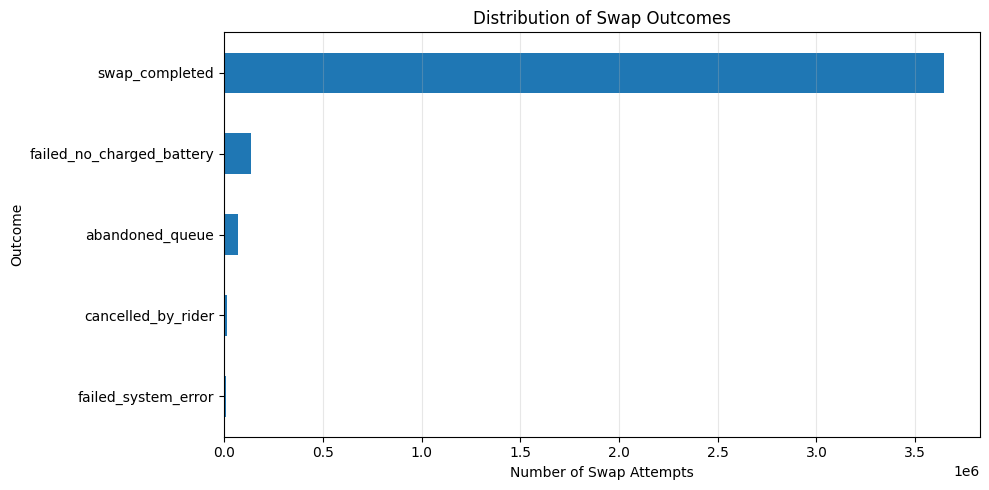

In [10]:
outcome_counts = swap_events['event_type'].value_counts()

plt.figure(figsize=(10, 5))

outcome_counts.sort_values().plot(
    kind='barh'
)

plt.xlabel('Number of Swap Attempts')
plt.ylabel('Outcome')
plt.title('Distribution of Swap Outcomes')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Key Finding

Completed swaps account for the large majority of swap attempts, with an overall completion rate of approximately 94%.

Among unsuccessful attempts, `failed_no_charged_battery` is the dominant failure category, followed by `abandoned_queue`. System errors and rider cancellations represent substantially smaller shares of unsuccessful attempts.

This indicates that the analysis should focus particularly on **battery availability and queue/service capacity**, rather than treating all failures as one homogeneous category.

In [11]:
total_attempts = len(swap_events)

completed_swaps = (
    swap_events['event_type'] == 'swap_completed'
).sum()

failed_attempts = total_attempts - completed_swaps

completion_rate = completed_swaps / total_attempts * 100
failure_rate = failed_attempts / total_attempts * 100

print(f"Total attempts   : {total_attempts:,}")
print(f"Completed swaps  : {completed_swaps:,}")
print(f"Failed attempts  : {failed_attempts:,}")
print(f"Completion rate  : {completion_rate:.2f}%")
print(f"Failure rate     : {failure_rate:.2f}%")

Total attempts   : 3,877,013
Completed swaps  : 3,645,809
Failed attempts  : 231,204
Completion rate  : 94.04%
Failure rate     : 5.96%


## 1.2 Initial Findings — Swap Outcomes

The `swap_events` table contains 3,877,013 swap attempts across the network.

Approximately 94% of attempts resulted in a completed swap, which is consistent with the problem statement's indication that about 94% of attempts are completed.

Among unsuccessful attempts, `failed_no_charged_battery` is the largest failure category, followed by `abandoned_queue`. Rider cancellations and system errors account for a much smaller share of unsuccessful attempts.

This suggests that battery availability and queue experience may be more important service-quality issues than system errors. However, this is only a network-wide observation. Further analysis is required to determine whether these issues are concentrated in particular stations, cities, time periods, vehicle classes, or operating conditions.

## 1.3 Network Performance — Headline KPIs

Before investigating individual drivers, we establish the network-wide baseline using all swap attempts from January 2024 to June 2025.

These KPIs provide the starting point for evaluating how service performance changes across time, stations, geography, equipment, and rider segments.

In [12]:
kpi_summary = pd.DataFrame({
    'KPI': [
        'Total Swap Attempts',
        'Completed Swaps',
        'Failed / Uncompleted Attempts',
        'Completion Rate',
        'Failure Rate'
    ],
    'Value': [
        total_attempts,
        completed_swaps,
        failed_attempts,
        f'{completion_rate:.2f}%',
        f'{failure_rate:.2f}%'
    ]
})

kpi_summary

,KPI,Value
0,Total Swap Attempts,3877013
1,Completed Swaps,3645809
2,Failed / Uncompleted Attempts,231204
3,Completion Rate,94.04%
4,Failure Rate,5.96%


## 1.4 Network Performance Over Time

The first analytical question is whether network performance has improved or deteriorated over the 18-month operating period.

We begin by aggregating swap activity at the monthly level. This allows us to identify changes in demand, successful service delivery, and revenue over time before investigating the operational factors behind those changes.

In [14]:
# Ensure event timestamp is in datetime format
swap_events['event_ts'] = pd.to_datetime(
    swap_events['event_ts'],
    errors='coerce'
)

# Check for any timestamps that could not be parsed
print("Unparsed timestamps:", swap_events['event_ts'].isna().sum())
swap_events['month'] = swap_events['event_ts'].dt.to_period('M')

monthly_performance = (
    swap_events
    .groupby('month')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_type', lambda x: (x == 'swap_completed').sum()),
        revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

monthly_performance['failed_attempts'] = (
    monthly_performance['total_attempts']
    - monthly_performance['completed_swaps']
)

monthly_performance['completion_rate'] = (
    monthly_performance['completed_swaps']
    / monthly_performance['total_attempts']
    * 100
)

monthly_performance

Unparsed timestamps: 0


,month,total_attempts,completed_swaps,revenue_inr,failed_attempts,completion_rate
0,2024-01,110348,105490,6318995.20,4858,95.597564
1,2024-02,111531,106582,6387614.80,4949,95.562669
2,2024-03,123900,118444,7093617.00,5456,95.596449
3,2024-04,131818,122836,7370255.80,8982,93.186060
4,2024-05,146278,128328,7689594.00,17950,87.728845
5,2024-06,148888,133743,8003275.60,15145,89.827924
6,2024-07,158688,151824,9879524.60,6864,95.674531
7,2024-08,172295,164931,10724296.65,7364,95.725935
8,2024-09,195885,187302,12115209.50,8583,95.618347
9,2024-10,229901,219838,14577271.65,10063,95.622899


### 1.4.1 Monthly Swap Activity

Swap demand increased substantially over the study period. We visualize total attempts and completed swaps to understand whether network growth was accompanied by successful service delivery.

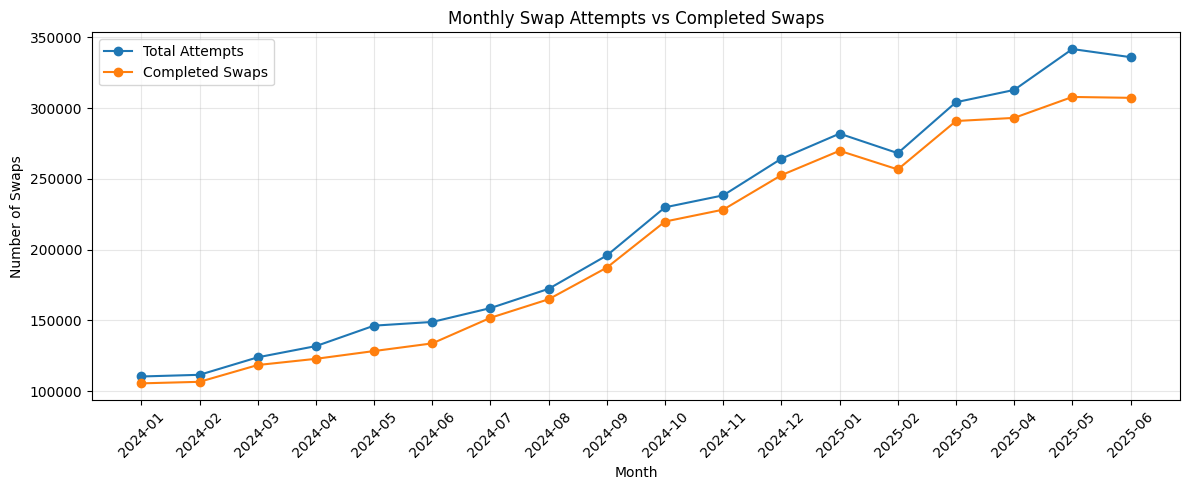

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance['month'].astype(str),
    monthly_performance['total_attempts'],
    marker='o',
    label='Total Attempts'
)

plt.plot(
    monthly_performance['month'].astype(str),
    monthly_performance['completed_swaps'],
    marker='o',
    label='Completed Swaps'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Number of Swaps')
plt.title('Monthly Swap Attempts vs Completed Swaps')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4.2 Monthly Completion Rate

While swap volume measures network growth, completion rate measures the reliability of service delivery. Examining this metric separately prevents high transaction volume from masking deterioration in service quality.

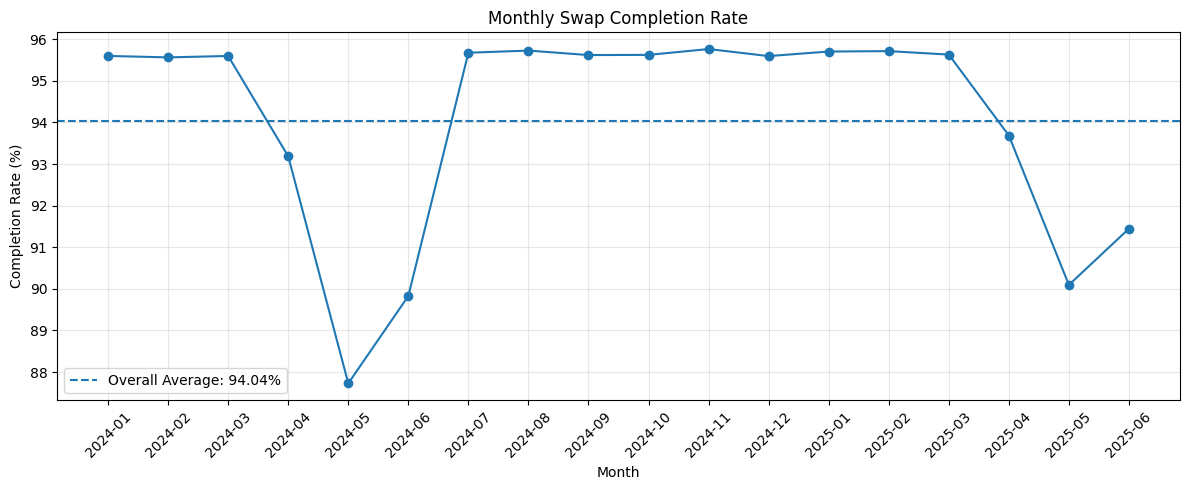

In [16]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance['month'].astype(str),
    monthly_performance['completion_rate'],
    marker='o'
)

plt.axhline(
    completion_rate,
    linestyle='--',
    label=f'Overall Average: {completion_rate:.2f}%'
)

plt.xticks(rotation=45)
plt.xlabel('Month')
plt.ylabel('Completion Rate (%)')
plt.title('Monthly Swap Completion Rate')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 1.4.3 Key Findings — Network Performance Over Time

Network activity increased substantially throughout the study period, with monthly swap attempts rising from approximately 110 thousand in January 2024 to more than 340 thousand in May 2025.

However, service reliability did not improve consistently with network growth. Completion rates remained close to 95–96% during most months but experienced two pronounced periods of deterioration: April–June 2024 and April–June 2025.

The most notable deterioration occurred in May 2025, when completion rate fell to approximately 90%, despite the network handling its highest monthly swap volume.

This suggests that increasing demand and network scale may have created periods of operational stress. The pattern is an association rather than evidence of causation, so the next analysis will investigate the operational factors associated with these changes.

## Q1 — Executive Takeaway

- **Demand:** Monthly swap attempts increased substantially over the study period, rising from approximately 110K in January 2024 to more than 340K by May 2025.

- **Reliability:** Completion rates remained around 95–96% for most of the period but showed clear deterioration during April–June 2024 and April–June 2025.

- **Critical period:** May 2025 was the most notable deterioration, with completion rate falling to approximately 90% while the network was handling its highest monthly swap volume.

- **Operational implication:** The combination of rapidly increasing demand and weaker completion performance indicates periods of operational stress. The following questions therefore investigate the specific failure, waiting-time, energy, battery and station-level factors associated with network performance.

# Q2 — Service Failures & Customer Experience



### Business Question
**What are the major causes of unsuccessful swaps, and are poor customer waiting experiences associated with unsuccessful outcomes?**



### Objective
Quantify failure composition and test whether queue waiting time differs materially across swap outcomes.

The previous analysis established that unsuccessful swap attempts are concentrated in a small number of failure categories, particularly battery unavailability and queue abandonment.

This section investigates these failure modes in greater detail. First, we identify the major contributors to unsuccessful swaps. We then examine queue waiting times across different swap outcomes to determine whether longer waits are associated with unsuccessful or abandoned attempts.

The analysis is designed to distinguish between network-wide failure composition and the customer experience associated with those failures.


## 2.1 Failure Composition

Overall completion rate provides a useful network-level KPI, but it does not explain why swap attempts fail.

To identify actionable operational issues, failed and incomplete attempts are broken down by event type.

This analysis distinguishes between:
- Battery availability problems
- Queue abandonment
- Rider cancellations
- System-related failures

Understanding the composition of failures will help identify where operational interventions may have the greatest potential impact.

In [17]:
failure_analysis = (
    swap_events
    .groupby('event_type')
    .size()
    .reset_index(name='count')
)

failure_analysis['percentage'] = (
    failure_analysis['count']
    / failure_analysis['count'].sum()
    * 100
)

failure_analysis = failure_analysis.sort_values(
    'count',
    ascending=False
)

failure_analysis


,event_type,count,percentage
4,swap_completed,3645809,94.036543
2,failed_no_charged_battery,134389,3.466303
0,abandoned_queue,68533,1.767675
1,cancelled_by_rider,16712,0.431053
3,failed_system_error,11570,0.298426


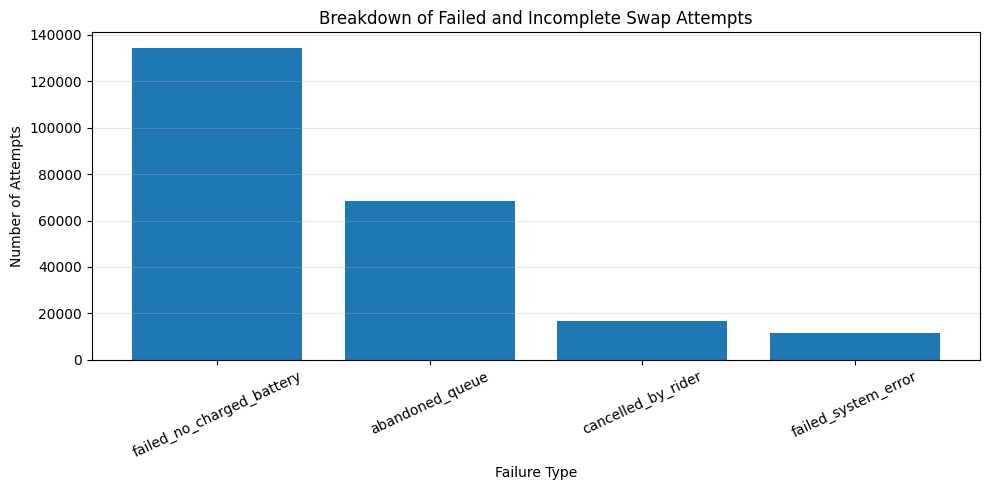

In [18]:
# Exclude successful swaps so the chart focuses only on failures
failure_only = failure_analysis[
    failure_analysis['event_type'] != 'swap_completed'
].copy()

plt.figure(figsize=(10, 5))

plt.bar(
    failure_only['event_type'],
    failure_only['count']
)

plt.xlabel('Failure Type')
plt.ylabel('Number of Attempts')
plt.title('Breakdown of Failed and Incomplete Swap Attempts')
plt.xticks(rotation=25)
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()

### Failure Composition — Key Finding

The failure breakdown shows that the largest contributor to unsuccessful swap attempts is `failed_no_charged_battery`, accounting for approximately 3.47% of all swap attempts.

Queue abandonment is the second-largest category at approximately 1.77%, while rider cancellations and system errors contribute relatively smaller shares.

This indicates that battery availability is a more prominent operational issue than system failures in the overall network. However, the network-level view may hide station-specific problems.

Therefore, the next analysis will examine whether failures due to lack of charged batteries are concentrated at particular stations.

## 2.2 Queue Experience and Waiting Time

### Business Question
**Do unsuccessful or abandoned swap attempts experience longer queue waits than completed swaps?**

We compare average, median and 90th-percentile queue wait by swap outcome. Median wait is the primary comparison because it is less sensitive to extreme waiting times.


In [19]:
queue_analysis = (
    swap_events.groupby('event_type')['queue_wait_sec']
    .agg(
        attempts='count',
        avg_queue_wait_sec='mean',
        median_queue_wait_sec='median',
        p90_queue_wait_sec=lambda x: x.quantile(0.90)
    )
    .reset_index()
    .sort_values('median_queue_wait_sec', ascending=False)
)

queue_analysis

,event_type,attempts,avg_queue_wait_sec,median_queue_wait_sec,p90_queue_wait_sec
0,abandoned_queue,68533,702.557906,648.0,1087.0
4,swap_completed,3645809,243.721747,209.0,424.0
1,cancelled_by_rider,16712,44.565701,44.0,81.0
3,failed_system_error,11570,44.417978,44.0,80.0
2,failed_no_charged_battery,134389,29.498121,30.0,53.0


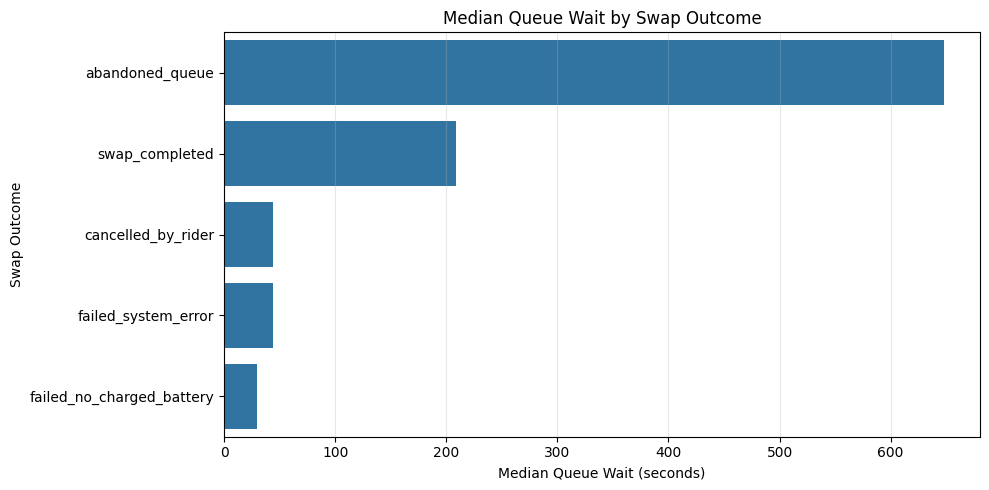

In [20]:
plt.figure(figsize=(10, 5))
sns.barplot(
    data=queue_analysis,
    x='median_queue_wait_sec',
    y='event_type'
)
plt.xlabel('Median Queue Wait (seconds)')
plt.ylabel('Swap Outcome')
plt.title('Median Queue Wait by Swap Outcome')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

### Key Finding

**Use the existing calculated result from the notebook:** abandoned queues have a median wait of **648 seconds (10.8 minutes)** versus **209 seconds (3.5 minutes)** for completed swaps, with the abandoned-queue P90 reaching **1,087 seconds (18.1 minutes)**.

**Interpretation:** Longer waits are strongly associated with queue abandonment in the observed data. This supports queue capacity/service-speed improvement as an operational lever for reducing incomplete swaps. Association should not be interpreted as proof that waiting time alone causes abandonment.


## Q2 — Final Answer

**Answer:** The failure mix is dominated by battery-unavailability failures, followed by queue abandonment. Queue abandonment is also associated with substantially longer waits than completed swaps. Therefore, Q2 should conclude with two operational themes: **battery availability** and **queue/service capacity**.


# Q3 — Station & Geographic Patterns

### Business Question
**Which stations show the greatest operational pressure, and where are battery-unavailability failures concentrated?**

### Objective
Compare station demand, completion performance and battery-unavailability failure rates/volumes to identify operational hotspots.

> The current notebook contains station-level analysis. A true city/geographic comparison should only be added if the dataset explicitly provides a reliable geographic field.


## 3.1 Station-Level Operational Performance

After examining battery-related drivers, the next step is to evaluate operational performance at the station level.

Stations differ in transaction volume, completion rates, and customer waiting times. A station with high swap volume may generate significant business value, but it may also experience operational pressure.

This section evaluates:
- Swap attempt volume by station
- Completion rate by station
- Average queue waiting time
- Station-level operational bottlenecks

The objective is to identify stations that require attention from a network-operations perspective.

In [21]:
station_analysis = (
    swap_events
    .groupby('station_id')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_type', lambda x: (x == 'swap_completed').sum()),
        avg_queue_wait_sec=('queue_wait_sec', 'mean'),
        total_revenue_inr=('amount_charged_inr', 'sum')
    )
    .reset_index()
)

station_analysis['completion_rate'] = (
    station_analysis['completed_swaps']
    / station_analysis['total_attempts']
    * 100
)

station_analysis['failure_rate'] = (
    100 - station_analysis['completion_rate']
)

station_analysis = station_analysis.sort_values(
    'total_attempts',
    ascending=False
)

station_analysis.head(10)

,station_id,total_attempts,completed_swaps,avg_queue_wait_sec,total_revenue_inr,completion_rate,failure_rate
18,STN-BLR-019,58067,55255,242.505037,3570935.50,95.157318,4.842682
3,STN-BLR-004,52094,49670,243.033727,3231081.40,95.346873,4.653127
71,STN-HYD-072,51765,47589,242.711214,2870922.95,91.932773,8.067227
69,STN-HYD-070,49688,45920,242.972368,2928321.25,92.416680,7.583320
42,STN-DEL-043,49597,45326,243.276166,2802302.45,91.388592,8.611408
93,STN-JAI-138,48945,44703,243.439636,2804974.60,91.333129,8.666871
49,STN-DEL-050,47060,43007,242.044284,2639130.25,91.387590,8.612410
135,STN-PUN-096,46174,43872,242.381643,2964613.20,95.014510,4.985490
64,STN-HYD-065,46001,42650,242.547771,2597473.60,92.715376,7.284624
96,STN-JAI-141,45594,41613,243.734088,2528249.90,91.268588,8.731412


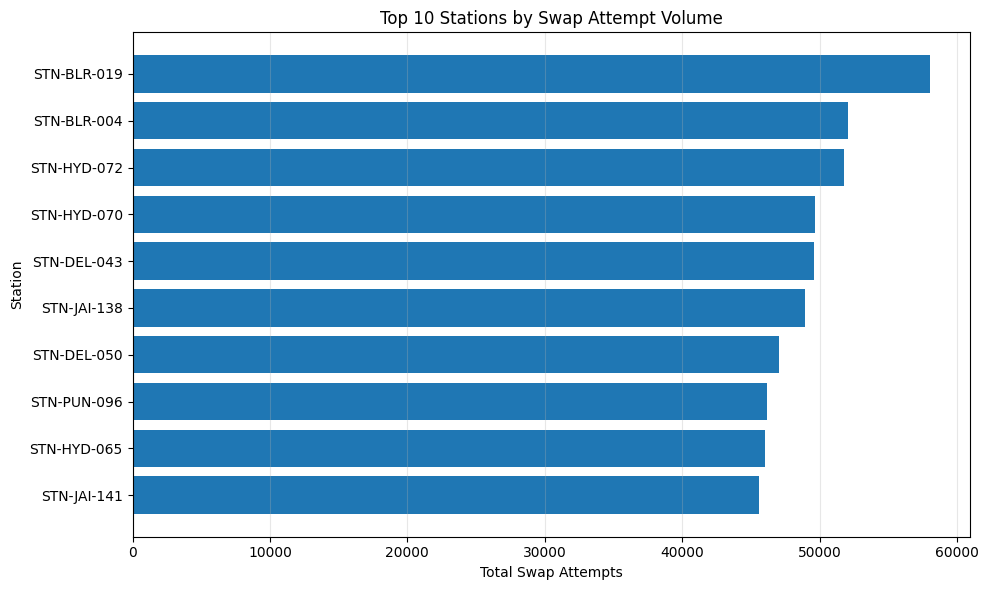

In [22]:
top_stations = station_analysis.head(10).sort_values(
    'total_attempts',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_stations['station_id'],
    top_stations['total_attempts']
)

plt.xlabel('Total Swap Attempts')
plt.ylabel('Station')
plt.title('Top 10 Stations by Swap Attempt Volume')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

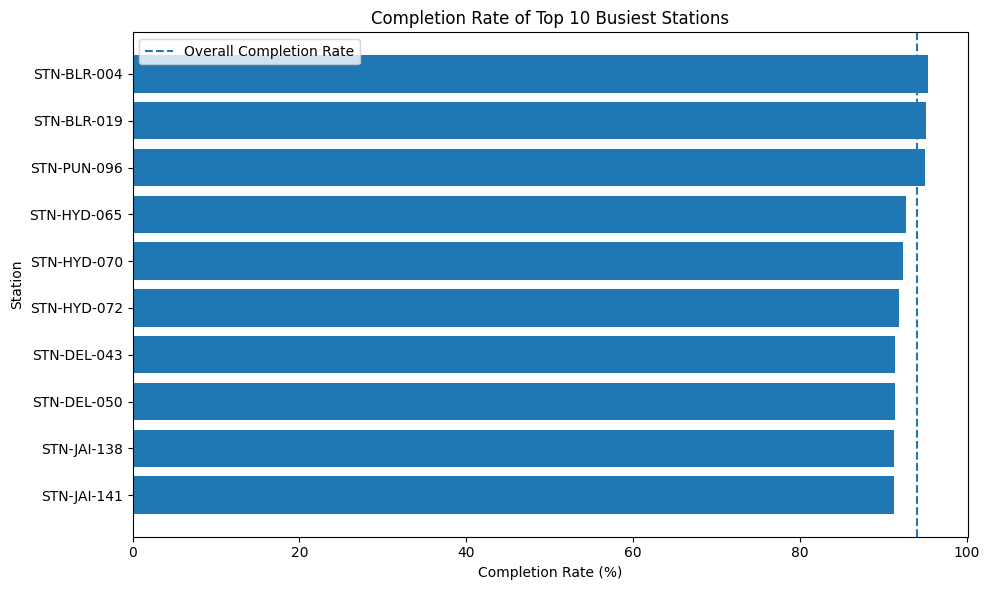

In [23]:
top_completion = station_analysis.sort_values(
    'total_attempts',
    ascending=False
).head(10).sort_values(
    'completion_rate',
    ascending=True
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_completion['station_id'],
    top_completion['completion_rate']
)

plt.axvline(
    94.04,
    linestyle='--',
    label='Overall Completion Rate'
)

plt.xlabel('Completion Rate (%)')
plt.ylabel('Station')
plt.title('Completion Rate of Top 10 Busiest Stations')
plt.legend()

plt.tight_layout()
plt.show()

### Key Findings

Station-level performance shows that swap activity is concentrated across a group of high-volume stations, with STN-BLR-019 recording the highest number of attempts at 58,067.

However, high transaction volume does not necessarily correspond to higher operational performance. Among the ten busiest stations, STN-BLR-004 recorded the highest completion rate at approximately 95.35%, while STN-JAI-141 recorded the lowest at approximately 91.27%.

Only three of the ten busiest stations exceeded the overall network completion rate of 94.04%. The remaining high-volume stations performed below the network benchmark, indicating potential operational inefficiencies at several important locations.

Average queue waiting time is relatively similar across the top stations, remaining close to 242–244 seconds. This suggests that differences in completion rates may not be explained by average queue time alone and should be investigated alongside other factors such as battery availability, station capacity, connectivity, and failure type.

## 3.2 Station-Level Battery Availability Analysis

Since `failed_no_charged_battery` is the largest failure category, the next step is to determine where these failures occur.

Identifying stations with a high number of battery-unavailability failures can help distinguish between:

- High-demand stations experiencing capacity pressure
- Stations with relatively weak battery replenishment
- Stations where failures are primarily a consequence of high transaction volume

Both absolute failure volume and failure rate will therefore be examined.

In [24]:
battery_failure_by_station = (
    swap_events
    .assign(
        battery_failure=lambda x:
        (x['event_type'] == 'failed_no_charged_battery').astype(int)
    )
    .groupby('station_id')
    .agg(
        total_attempts=('event_id', 'count'),
        battery_failures=('battery_failure', 'sum')
    )
    .reset_index()
)

battery_failure_by_station['battery_failure_rate'] = (
    battery_failure_by_station['battery_failures']
    / battery_failure_by_station['total_attempts']
    * 100
)

battery_failure_by_station = battery_failure_by_station.sort_values(
    'battery_failures',
    ascending=False
)

battery_failure_by_station.head(10)

,station_id,total_attempts,battery_failures,battery_failure_rate
93,STN-JAI-138,48945,2635,5.383594
42,STN-DEL-043,49597,2611,5.264431
71,STN-HYD-072,51765,2530,4.887472
49,STN-DEL-050,47060,2513,5.339992
96,STN-JAI-141,45594,2474,5.426153
92,STN-JAI-137,44371,2380,5.363864
95,STN-JAI-140,44115,2347,5.320186
69,STN-HYD-070,49688,2311,4.651022
89,STN-JAI-134,42925,2221,5.174141
46,STN-DEL-047,41594,2141,5.147377


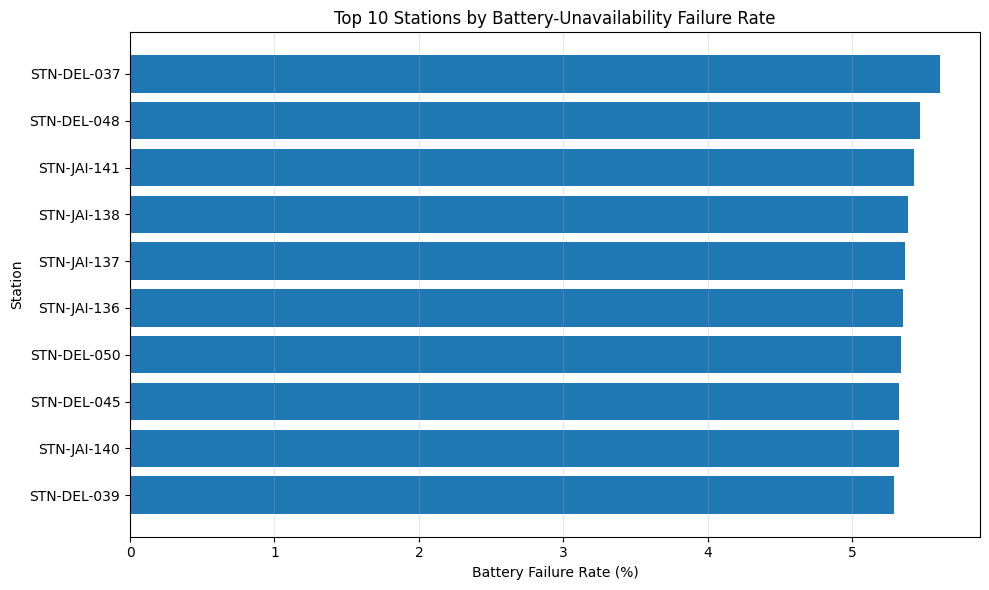

In [25]:
top_battery_rate = (
    battery_failure_by_station
    .sort_values('battery_failure_rate', ascending=False)
    .head(10)
    .sort_values('battery_failure_rate', ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_battery_rate['station_id'],
    top_battery_rate['battery_failure_rate']
)

plt.xlabel('Battery Failure Rate (%)')
plt.ylabel('Station')
plt.title('Top 10 Stations by Battery-Unavailability Failure Rate')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

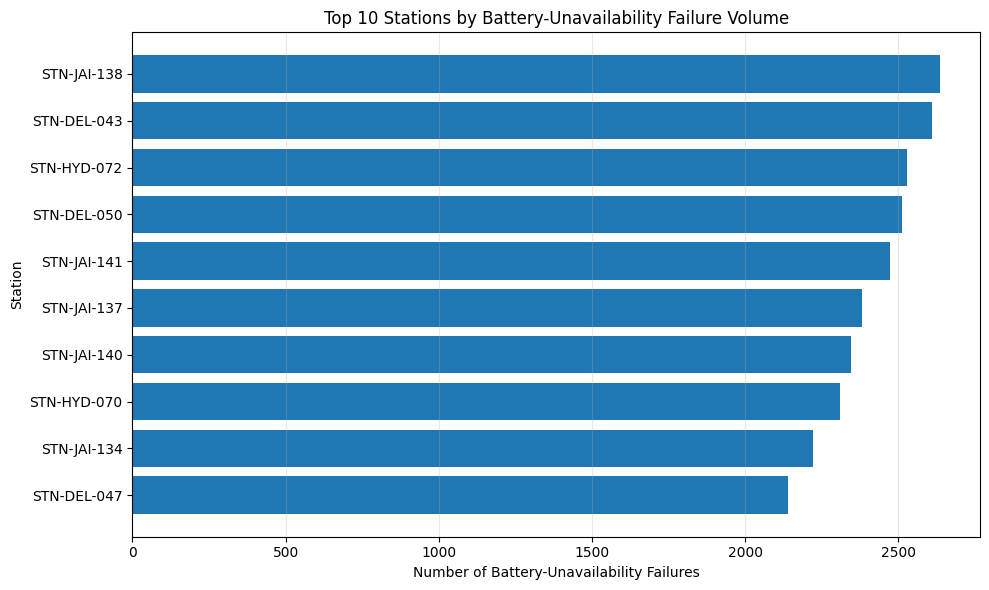

In [26]:
top_battery_volume = (
    battery_failure_by_station
    .sort_values('battery_failures', ascending=False)
    .head(10)
    .sort_values('battery_failures', ascending=True)
)

plt.figure(figsize=(10, 6))

plt.barh(
    top_battery_volume['station_id'],
    top_battery_volume['battery_failures']
)

plt.xlabel('Number of Battery-Unavailability Failures')
plt.ylabel('Station')
plt.title('Top 10 Stations by Battery-Unavailability Failure Volume')
plt.grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

### Analysis: Battery-Unavailability Failures

Battery unavailability is the largest failure category, accounting for approximately 3.47% of all swap attempts. The station-level analysis shows that the problem is not evenly distributed across the network.

The highest failure-rate stations record battery-unavailability rates above 5%, indicating that some stations experience materially greater battery availability issues than the overall network. Several of these stations also appear among the highest in absolute failure volume.

This suggests that battery availability should be investigated at the station level, particularly at locations that combine high failure rates with high failure volumes. Possible operational factors include inadequate battery replenishment, demand exceeding available charged inventory, or differences in station-level battery management.

**Business implication:** Prioritising high-impact stations for battery inventory and replenishment analysis could help reduce failed swap attempts and improve overall swap completion performance.

## Q3 — Final Answer
## Q3 — Final Answer

### Answer

Operational pressure is concentrated at a subset of high-volume stations where completion performance is below the network benchmark and battery-unavailability failures are relatively high.

- **STN-BLR-019** handled the highest swap-attempt volume, with approximately **58,067 attempts**, showing that it is one of the network's highest-demand locations.
- However, high demand does not automatically indicate poor performance. Among the ten busiest stations, completion rates ranged from approximately **91.27% to 95.35%**, compared with an overall network completion rate of approximately **94.04%**.
- **STN-JAI-141** recorded the lowest completion rate among the top ten busiest stations at approximately **91.27%**, while also recording a high battery-unavailability failure rate of approximately **5.43%**.
- Battery-unavailability failures are concentrated at several stations. **STN-JAI-138** recorded the highest absolute number of battery-unavailability failures at approximately **2,635**, followed by **STN-DEL-043 (2,611)**, **STN-HYD-072 (2,530)** and **STN-DEL-050 (2,513)**.
- Several stations also recorded battery-unavailability failure rates above **5%**, indicating that the issue is not explained by transaction volume alone.

### Business Interpretation

The analysis suggests that the most important operational hotspots are stations where **high demand, below-benchmark completion and elevated battery-unavailability failures overlap**. In particular, stations such as **STN-JAI-141, STN-JAI-138, STN-DEL-043 and STN-DEL-050** warrant closer investigation because they combine relatively weak completion performance with significant battery-related failures.

At the same time, the results show that **volume alone should not be treated as evidence of operational failure**. Average queue waiting time among the busiest stations is relatively similar, at approximately **242–244 seconds**, so differences in completion performance may involve battery availability, station capacity or other station-level factors.

**Business implication:** Prioritising high-volume stations with both below-benchmark completion and elevated battery-unavailability rates can help target battery replenishment, inventory planning and station-capacity investigations where they are most likely to improve network performance.

# Q4 — Battery & Equipment Performance

### Business Question
**How do battery state-of-charge and state-of-health relate to recharge energy requirements?**

### Objective
Determine whether battery condition/charging state helps explain variation in energy requirements.


## Q4.0 Analytical Base — Completed Swaps

The following existing cell creates the completed-swap analytical dataset and calculates energy cost from recharge energy and station tariff. It is retained here so later battery analyses use the same completed-swap population.


In [27]:
# Keep only completed swaps
completed = swap_events[
    swap_events['event_type'] == 'swap_completed'
].copy()

# Add station electricity tariff
completed = completed.merge(
    stations[['station_id', 'grid_tariff_inr_kwh']],
    on='station_id',
    how='left'
)

# Calculate energy cost
completed['energy_cost_inr'] = (
    completed['energy_to_recharge_kwh']
    * completed['grid_tariff_inr_kwh']
)

# Check the result
completed[
    ['event_id',
     'station_id',
     'energy_to_recharge_kwh',
     'grid_tariff_inr_kwh',
     'energy_cost_inr']
].head()

,event_id,station_id,energy_to_recharge_kwh,grid_tariff_inr_kwh,energy_cost_inr
0,SW-000000001,STN-MUM-115,2.035,9.47,19.27145
1,SW-000000002,STN-HYD-070,2.157,9.19,19.82283
2,SW-000000003,STN-DEL-046,2.039,8.55,17.43345
3,SW-000000004,STN-JAI-135,2.194,10.51,23.05894
4,SW-000000005,STN-PUN-100,1.971,8.31,16.37901


### 4.1 Battery State-of-Charge and Energy Requirement

Energy required for recharging should be related to the battery's state of charge when it enters the station.

To investigate this relationship, we compare the initial battery SOC (`soc_in_pct`) with the amount of energy required for recharge. This helps determine whether lower incoming battery charge levels are associated with higher energy consumption.

In [28]:
# Create SOC bands for easier comparison

completed['soc_in_band'] = pd.cut(
    completed['soc_in_pct'],
    bins=[0, 20, 40, 60, 80, 100],
    labels=['0-20%', '20-40%', '40-60%', '60-80%', '80-100%']
)

soc_analysis = (
    completed.groupby('soc_in_band', observed=False)
    .agg(
        swaps=('event_id', 'count'),
        avg_soc_in=('soc_in_pct', 'mean'),
        avg_energy_kwh=('energy_to_recharge_kwh', 'mean'),
        median_energy_kwh=('energy_to_recharge_kwh', 'median')
    )
    .reset_index()
)

soc_analysis

,soc_in_band,swaps,avg_soc_in,avg_energy_kwh,median_energy_kwh
0,0-20%,3627509,9.226747,2.094399,1.871
1,20-40%,18300,21.151443,1.800347,1.619
2,40-60%,0,NaN,NaN,NaN
3,60-80%,0,NaN,NaN,NaN
4,80-100%,0,NaN,NaN,NaN


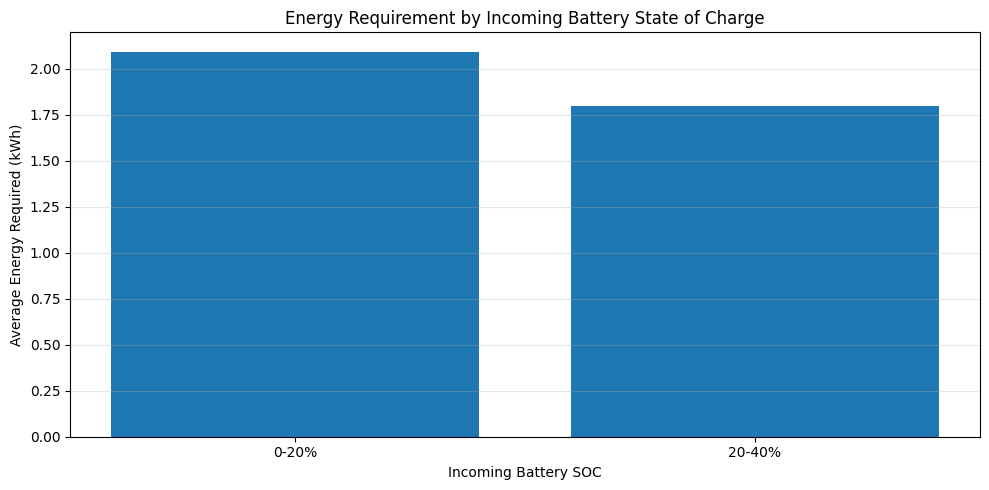

In [29]:
plt.figure(figsize=(10, 5))

plt.bar(
    soc_analysis['soc_in_band'],
    soc_analysis['avg_energy_kwh']
)

plt.xlabel('Incoming Battery SOC')
plt.ylabel('Average Energy Required (kWh)')
plt.title('Energy Requirement by Incoming Battery State of Charge')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Key Finding

Incoming battery SOC shows a clear difference in energy requirement within the observed range. Completed swaps with an incoming SOC of **0–20% required an average of approximately 2.09 kWh**, compared with **1.80 kWh for the 20–40% group**.

This represents an approximate **16% higher energy requirement** for the lower-SOC group.

However, the analysis also reveals an important data characteristic: virtually all completed swaps have an incoming SOC below 20%, while only a small number fall between 20% and 40%. No completed swaps are observed above 40% SOC in this dataset.

Therefore, the relationship should be interpreted only within the observed SOC range rather than extrapolated to higher SOC levels.

### 4.2 Quantifying the Relationship Between SOC and Energy Requirement

The SOC-band analysis suggests that lower incoming battery SOC is associated with higher energy requirements.

To quantify this relationship, we calculate the correlation between incoming SOC and recharge energy. A negative correlation would indicate that higher incoming SOC tends to be associated with lower energy requirements.

In [30]:
# Calculate correlation between incoming SOC and recharge energy

soc_energy_corr = completed[
    ['soc_in_pct', 'energy_to_recharge_kwh']
].corr()

soc_energy_corr

,soc_in_pct,energy_to_recharge_kwh
soc_in_pct,1.000000,-0.118198
energy_to_recharge_kwh,-0.118198,1.000000


In [31]:
print(
    f"Correlation between incoming SOC and energy required: "
    f"{soc_energy_corr.loc['soc_in_pct', 'energy_to_recharge_kwh']:.3f}"
)

Correlation between incoming SOC and energy required: -0.118


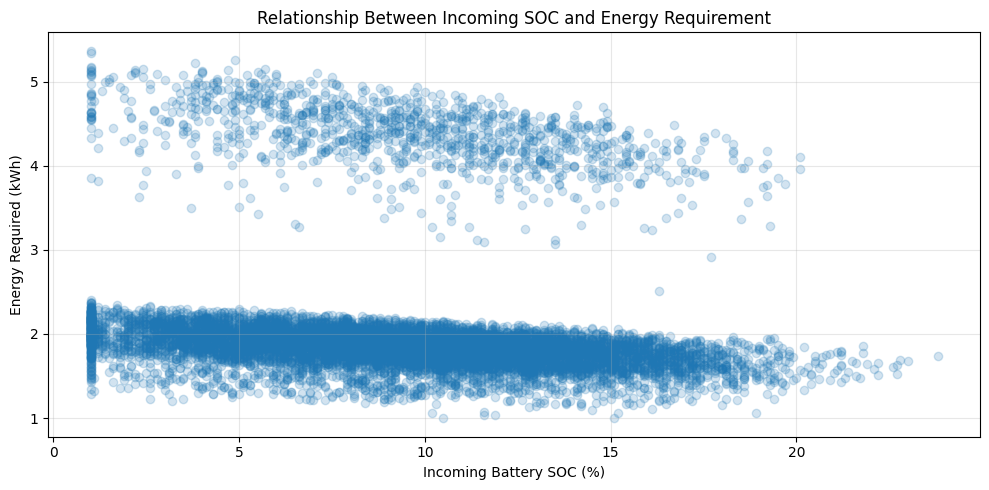

In [32]:
sample = completed[
    ['soc_in_pct', 'energy_to_recharge_kwh']
].dropna().sample(
    n=min(10000, len(completed)),
    random_state=42
)

plt.figure(figsize=(10, 5))

plt.scatter(
    sample['soc_in_pct'],
    sample['energy_to_recharge_kwh'],
    alpha=0.2
)

plt.xlabel('Incoming Battery SOC (%)')
plt.ylabel('Energy Required (kWh)')
plt.title('Relationship Between Incoming SOC and Energy Requirement')
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

#### Key Finding

The correlation between incoming battery SOC and recharge energy is **−0.118**, indicating a weak negative relationship. In general, batteries arriving with higher SOC tend to require slightly less recharge energy, which is directionally consistent with the expected charging behavior.

However, the relationship is not strong enough to explain energy consumption on its own. The scatter plot shows substantial variation in recharge energy at similar SOC levels, suggesting that other factors such as battery condition, battery generation, station characteristics, or operational factors may also influence energy requirements.

This indicates that energy-cost optimization should not rely on SOC alone. The next analysis therefore examines **battery health (SOH)** to determine whether battery condition is associated with energy requirements.

### 4.3 Battery Health and Energy Requirement

State of charge explains how much charge is currently available in the battery, while state of health (SOH) represents the battery's overall condition relative to its original capacity.

We now examine whether battery health is associated with recharge energy requirements. This can help identify whether battery condition should be considered when optimizing charging operations and battery allocation.

In [33]:
soh_analysis = (
    completed
    .assign(
        soh_band=pd.cut(
            completed['soh_in_pct'],
            bins=[0, 80, 90, 95, 100, 110],
            labels=['<80%', '80-90%', '90-95%', '95-100%', '>100%']
        )
    )
    .groupby('soh_band', observed=False)
    .agg(
        swaps=('event_id', 'count'),
        avg_soh=('soh_in_pct', 'mean'),
        avg_energy_kwh=('energy_to_recharge_kwh', 'mean'),
        median_energy_kwh=('energy_to_recharge_kwh', 'median')
    )
    .reset_index()
)

soh_analysis

,soh_band,swaps,avg_soh,avg_energy_kwh,median_energy_kwh
0,<80%,396719,71.814535,1.680346,1.648
1,80-90%,1567847,85.532923,1.893775,1.773
2,90-95%,936110,92.503994,2.323197,1.969
3,95-100%,741907,97.241269,2.442030,2.063
4,>100%,3226,100.254433,2.509412,2.101


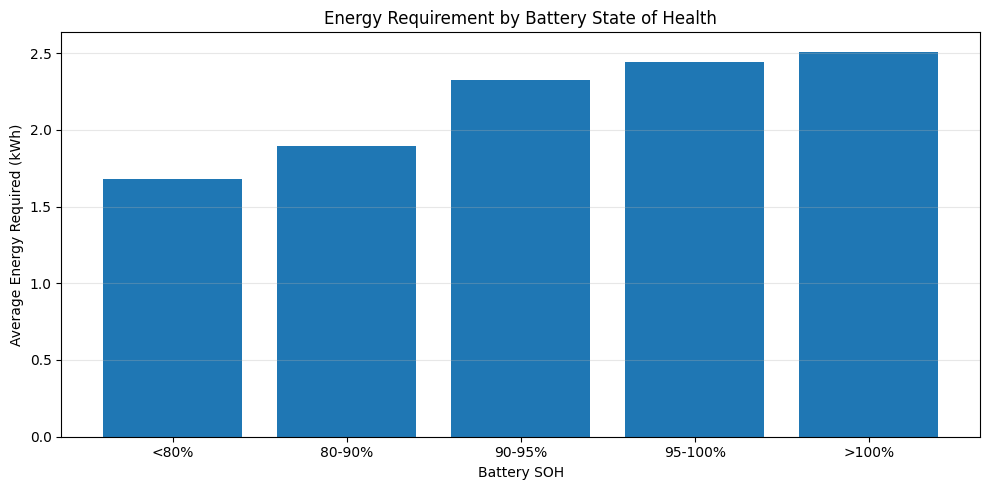

In [34]:
plt.figure(figsize=(10, 5))

plt.bar(
    soh_analysis['soh_band'],
    soh_analysis['avg_energy_kwh']
)

plt.xlabel('Battery SOH')
plt.ylabel('Average Energy Required (kWh)')
plt.title('Energy Requirement by Battery State of Health')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

In [35]:
soh_energy_corr = completed[
    ['soh_in_pct', 'energy_to_recharge_kwh']
].corr()

print(
    f"Correlation between incoming SOH and energy required: "
    f"{soh_energy_corr.loc['soh_in_pct', 'energy_to_recharge_kwh']:.3f}"
)

Correlation between incoming SOH and energy required: 0.341


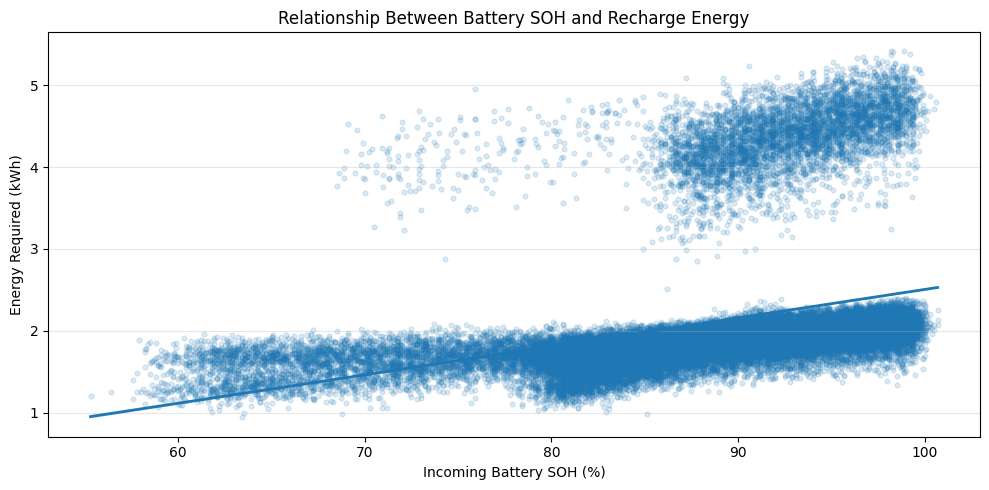

In [36]:
import seaborn as sns
import matplotlib.pyplot as plt

soh_sample = completed[
    ['soh_in_pct', 'energy_to_recharge_kwh']
].dropna().sample(
    n=min(50000, len(completed)),
    random_state=42
)

plt.figure(figsize=(10, 5))

sns.regplot(
    data=soh_sample,
    x='soh_in_pct',
    y='energy_to_recharge_kwh',
    scatter_kws={'alpha': 0.15, 's': 12},
    line_kws={'linewidth': 2}
)

plt.xlabel('Incoming Battery SOH (%)')
plt.ylabel('Energy Required (kWh)')
plt.title('Relationship Between Battery SOH and Recharge Energy')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

## Q4 — Final Answer
### Key Finding

Battery state-of-charge and state-of-health show different relationships with recharge energy.

Lower incoming SOC is associated with higher recharge requirements: batteries entering with 0–20% SOC require approximately 2.09 kWh on average, compared with 1.80 kWh for the 20–40% group. However, the SOC-energy correlation of −0.118 indicates that SOC alone has limited explanatory power.

Battery SOH shows a stronger positive association with recharge energy. Average energy requirement increases progressively across the observed SOH bands, from approximately 1.68 kWh for batteries below 80% SOH to approximately 2.51 kWh for batteries above 100% SOH. The raw SOH-energy correlation is 0.341.

Overall, battery condition and charging state are associated with recharge-energy requirements, but neither variable alone explains the full variation. This suggests that battery characteristics should be considered alongside other operational factors when planning charging and battery allocation.

# Q5 — Pricing & Economics

### Business Question
**How do energy consumption and grid tariffs affect the cost and economics of a completed battery swap?**

### Objective
Separate the effects of transaction revenue, energy consumption and electricity tariffs.

> The current notebook contains revenue-per-completed-swap and energy-cost/tariff analyses. A formal contribution margin should only be presented if the required cost components are actually calculated and validated.


## 5.1 Revenue Performance Over Time

Growth in swap volume does not necessarily translate into proportional revenue growth.

We therefore examine monthly revenue alongside completed swap activity and calculate revenue per completed swap to determine whether the economics of each completed transaction have changed over time.

In [37]:
monthly_performance['revenue_per_completed_swap'] = (
    monthly_performance['revenue_inr']
    / monthly_performance['completed_swaps']
)

monthly_performance[['month',
                     'completed_swaps',
                     'revenue_inr',
                     'revenue_per_completed_swap']]

,month,completed_swaps,revenue_inr,revenue_per_completed_swap
0,2024-01,105490,6318995.20,59.901367
1,2024-02,106582,6387614.80,59.931459
2,2024-03,118444,7093617.00,59.890049
3,2024-04,122836,7370255.80,60.000780
4,2024-05,128328,7689594.00,59.921405
5,2024-06,133743,8003275.60,59.840706
6,2024-07,151824,9879524.60,65.072219
7,2024-08,164931,10724296.65,65.022929
8,2024-09,187302,12115209.50,64.682756
9,2024-10,219838,14577271.65,66.309153


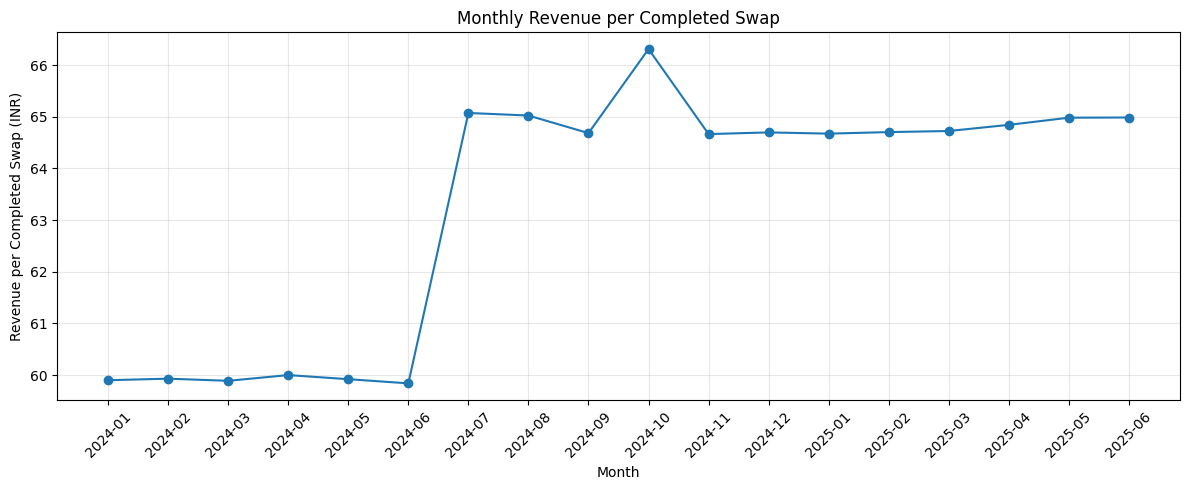

In [38]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_performance['month'].astype(str),
    monthly_performance['revenue_per_completed_swap'],
    marker='o'
)

plt.xlabel('Month')
plt.ylabel('Revenue per Completed Swap (INR)')
plt.title('Monthly Revenue per Completed Swap')
plt.xticks(rotation=45)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### 5.1 Key Findings — Revenue per Completed Swap

Revenue per completed swap remained relatively stable at approximately ₹59–60 during the first half of 2024 before increasing sharply from July 2024 onward.

From July 2024 through June 2025, revenue per completed swap remained broadly stable at approximately ₹65 per completed swap, with only modest month-to-month variation.

This indicates that the substantial growth in total revenue was driven primarily by increasing swap volume, while the revenue generated per successful transaction remained relatively stable after the mid-2024 pricing change.

Importantly, the deterioration in completion rates observed in April–June 2025 did not coincide with a comparable decline in revenue per completed swap. Therefore, the weakening service performance and the revenue trend appear to be different operational/economic signals and should be investigated separately.

## 5.2 Contribution Margin per Completed Swap

Revenue alone does not indicate whether the network is becoming more profitable.

To assess the economics of completed swaps, we construct an analytical contribution-margin proxy using the direct operating costs available in the dataset. The calculation will account for energy consumption, battery wear, and allocated station operating costs.

Because the dataset does not provide a formal accounting definition of contribution margin, this metric should be interpreted as an analytical proxy rather than reported accounting profit.

### 5.2.1 Energy Cost per Completed Swap

Energy cost is estimated using the electricity consumed to recharge the returned battery and the local station electricity tariff.

Only completed swaps with valid energy-consumption and station-tariff information are included in this calculation.

In [39]:
# Keep only completed swaps
completed = swap_events[
    swap_events['event_type'] == 'swap_completed'
].copy()

# Add station electricity tariff
completed = completed.merge(
    stations[['station_id', 'grid_tariff_inr_kwh']],
    on='station_id',
    how='left'
)

# Calculate energy cost
completed['energy_cost_inr'] = (
    completed['energy_to_recharge_kwh']
    * completed['grid_tariff_inr_kwh']
)

# Check the result
completed[
    ['event_id',
     'station_id',
     'energy_to_recharge_kwh',
     'grid_tariff_inr_kwh',
     'energy_cost_inr']
].head()

,event_id,station_id,energy_to_recharge_kwh,grid_tariff_inr_kwh,energy_cost_inr
0,SW-000000001,STN-MUM-115,2.035,9.47,19.27145
1,SW-000000002,STN-HYD-070,2.157,9.19,19.82283
2,SW-000000003,STN-DEL-046,2.039,8.55,17.43345
3,SW-000000004,STN-JAI-135,2.194,10.51,23.05894
4,SW-000000005,STN-PUN-100,1.971,8.31,16.37901


### 5.2.2 Energy Cost Validation

Before incorporating energy cost into contribution margin, we examine its distribution to identify missing values or extreme observations that could distort the profitability analysis.

In [40]:
completed['energy_cost_inr'].describe()

,energy_cost_inr
count,3.645809e+06
mean,1.949831e+01
std,7.787826e+00
min,6.915000e+00
25%,1.567266e+01
50%,1.739259e+01
75%,1.930775e+01
max,6.117930e+01


In [41]:
completed['energy_cost_inr'].isna().sum()

np.int64(0)

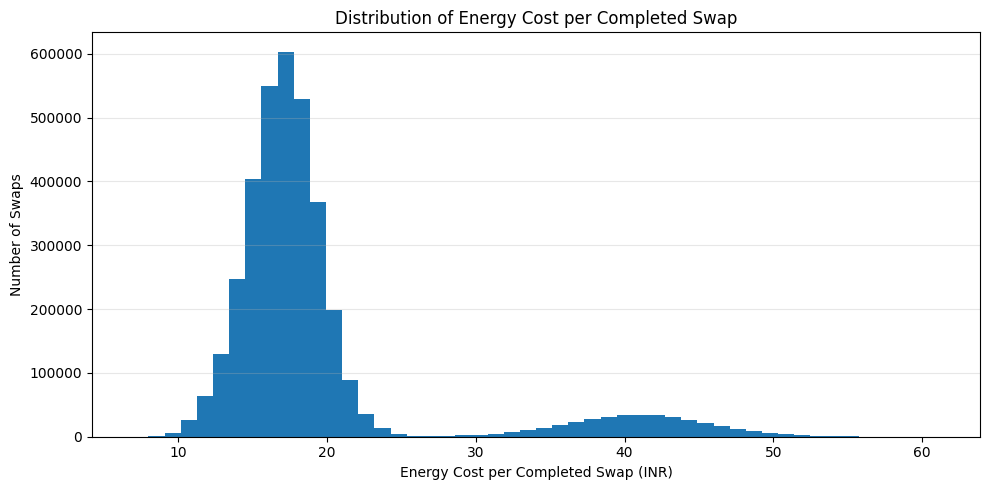

In [42]:
plt.figure(figsize=(10, 5))

plt.hist(
    completed['energy_cost_inr'].dropna(),
    bins=50
)

plt.xlabel('Energy Cost per Completed Swap (INR)')
plt.ylabel('Number of Swaps')
plt.title('Distribution of Energy Cost per Completed Swap')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

### 5.2.3 Investigating Energy Cost Drivers

Energy cost per completed swap is calculated from the energy required to recharge the battery and the applicable grid electricity tariff.

The distribution shows a concentration of swaps at lower energy costs, along with a smaller higher-cost group. This suggests that differences in energy consumption, electricity tariffs, or both may be driving the variation.

We therefore examine energy cost across tariff categories to identify whether certain pricing conditions are associated with systematically higher charging costs.

### Business Question

How do energy consumption and grid tariff variation affect the energy cost of a completed battery swap?

In [43]:
# Average energy cost by tariff code

tariff_analysis = (
    completed.groupby('tariff_code')
    .agg(
        swaps=('event_id', 'count'),
        avg_energy_cost_inr=('energy_cost_inr', 'mean'),
        median_energy_cost_inr=('energy_cost_inr', 'median')
    )
    .sort_values('avg_energy_cost_inr', ascending=False)
)

tariff_analysis

,swaps,avg_energy_cost_inr,median_energy_cost_inr
tariff_code,,,
PARTNER,2409841,20.176448,17.54848
STD,1030037,18.344057,17.31636
OFFPEAK,36098,17.339975,16.28101
PEAK,169833,17.335248,16.27028


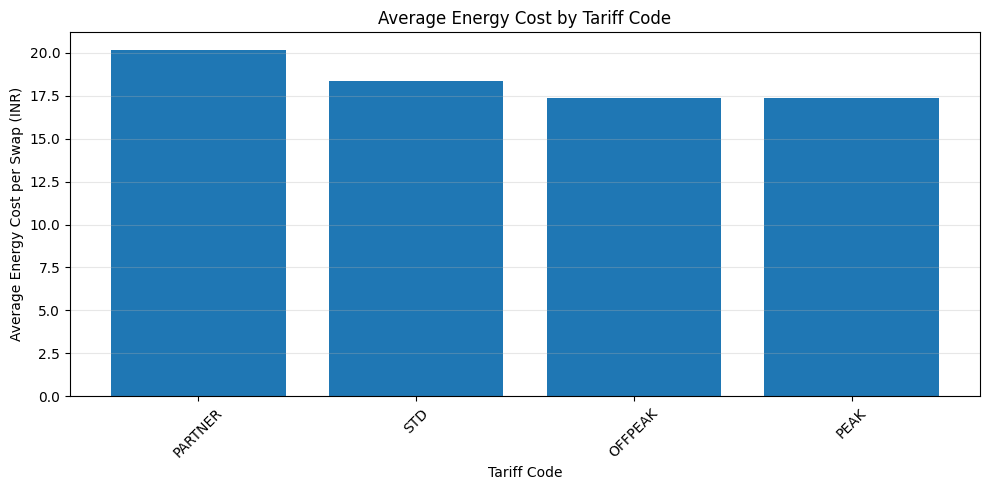

In [44]:
plt.figure(figsize=(10, 5))

plt.bar(
    tariff_analysis.index,
    tariff_analysis['avg_energy_cost_inr']
)

plt.xlabel('Tariff Code')
plt.ylabel('Average Energy Cost per Swap (INR)')
plt.title('Average Energy Cost by Tariff Code')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Key Finding

Partner-tariff swaps have the highest average energy cost at approximately **₹20.18 per completed swap**, compared with **₹18.34 for STD**, **₹17.34 for OFFPEAK**, and **₹17.34 for PEAK**.

The difference between the highest and lowest average tariff categories is roughly **₹2.84 per swap**. However, tariff code alone may not explain the full variation because energy cost also depends on the amount of energy required to recharge each battery.

Therefore, the next step is to separate the effect of **electricity tariff** from the effect of **energy consumption per swap**.

### 5.2.4 Energy Consumption vs Tariff

To understand the source of energy-cost variation, we now examine the amount of energy required to recharge each battery.

Comparing energy consumption across tariff categories helps determine whether the higher cost observed for PARTNER transactions is primarily associated with higher electricity pricing, higher energy requirements, or a combination of both.

In [45]:
energy_tariff_analysis = (
    completed.groupby('tariff_code')
    .agg(
        swaps=('event_id', 'count'),
        avg_energy_kwh=('energy_to_recharge_kwh', 'mean'),
        median_energy_kwh=('energy_to_recharge_kwh', 'median'),
        avg_tariff_inr_kwh=('grid_tariff_inr_kwh', 'mean')
    )
    .sort_values('avg_energy_kwh', ascending=False)
)

energy_tariff_analysis

,swaps,avg_energy_kwh,median_energy_kwh,avg_tariff_inr_kwh
tariff_code,,,,
PARTNER,2409841,2.165366,1.886,9.314189
STD,1030037,1.966123,1.862,9.329498
PEAK,169833,1.879595,1.760,9.229123
OFFPEAK,36098,1.878577,1.759,9.235803


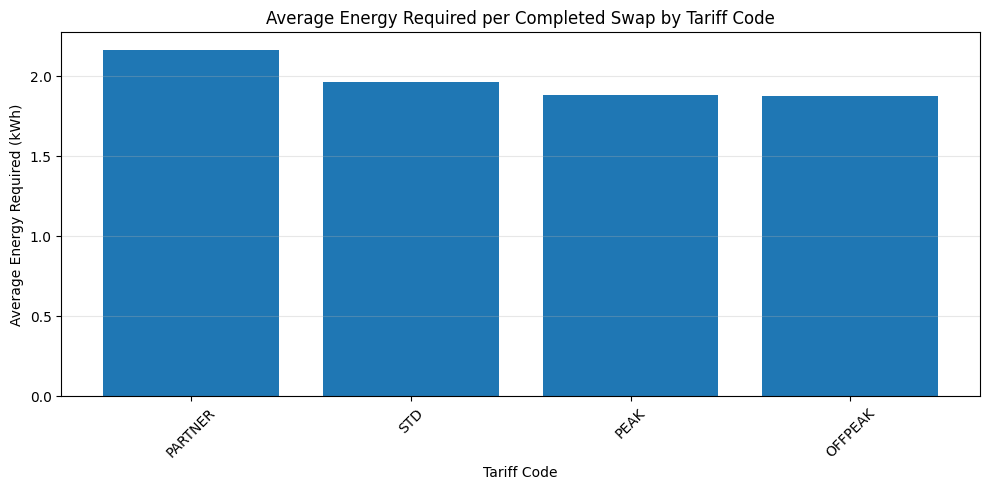

In [46]:
plt.figure(figsize=(10, 5))

plt.bar(
    energy_tariff_analysis.index,
    energy_tariff_analysis['avg_energy_kwh']
)

plt.xlabel('Tariff Code')
plt.ylabel('Average Energy Required (kWh)')
plt.title('Average Energy Required per Completed Swap by Tariff Code')
plt.xticks(rotation=45)
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

#### Key Finding

The comparison indicates that differences in energy consumption are a more important contributor to energy-cost variation than differences in electricity tariffs.

PARTNER swaps require the highest average energy at approximately **2.17 kWh per completed swap**, compared with approximately **1.97 kWh for STD** and **1.88 kWh for PEAK/OFFPEAK**. In contrast, the average grid tariff is relatively similar across all categories, ranging from approximately **₹9.23 to ₹9.33 per kWh**.

Therefore, the higher energy cost observed for PARTNER transactions is primarily associated with greater energy consumption per swap rather than a materially higher electricity tariff.

The next analysis examines whether battery state-of-charge (SOC) helps explain this difference in energy requirement.

## Q5 — Final Answer

## Q5 — Final Answer

Energy economics are driven more by energy consumption than by differences in grid tariffs.

Revenue per completed swap increased from approximately ₹59–60 during the first half of 2024 to around ₹65 from July 2024 onward, while completed-swap volume continued to increase substantially. This indicates that total revenue growth was primarily supported by higher transaction volume, with revenue per successful swap remaining broadly stable after the mid-2024 increase.

The average energy cost per completed swap is approximately ₹19.50, with a median of approximately ₹17.39. However, electricity tariffs are relatively similar across tariff categories, while energy consumption varies more materially.

PARTNER swaps require approximately 2.17 kWh on average, compared with approximately 1.97 kWh for STD and 1.88 kWh for PEAK/OFFPEAK. Since average tariffs remain within a narrow range of roughly ₹9.23–₹9.33 per kWh, the higher energy requirement is the more important driver of the observed energy-cost variation.

Therefore, the key economic lever is controlling energy consumption per completed swap rather than relying primarily on tariff differences. Revenue growth also depends heavily on maintaining transaction volume, while any profitability assessment should be treated cautiously because the available data does not provide a complete accounting-level contribution margin.

# Rider Retention & Engagement

## Business Question

What rider characteristics are associated with stronger engagement and retention, and where are potential rider-retention risks concentrated?

## Objective

The objective is to connect rider-level characteristics with actual swap activity to understand differences in rider engagement.

We examine rider activity across key attributes such as plan type, vehicle class, declared shift, home city, signup channel, age band and KYC verification status.

Rather than relying on rider characteristics alone, the analysis links the rider master data with swap-event activity to identify which rider segments are more or less active within the observed period.

# Q6 — Root Cause Analysis of Retention

### Business Question
**Which operational, service-quality or economic factors are associated with rider retention/churn?**


## Objective

Rider retention is the final customer-level outcome to investigate. While the earlier analyses identify operational issues such as battery unavailability, queue abandonment and station-level performance, Q6 examines whether these service experiences are associated with riders remaining active or churning.

The analysis will first establish the retention/churn baseline and then compare retained and churned riders across usage behaviour and service experience. Where a valid rider-level linkage exists, failed swaps, queue waiting time, battery availability and economic factors will also be examined.

The objective is to identify the strongest observed associations with rider retention and translate them into actionable business implications.


## 6.1 Rider Retention Baseline

Before testing potential drivers of churn, we first inspect the rider-level dataset to identify the retention/churn indicator and the variables available for rider-level analysis.# Q6 — Rider Retention & Engagement

## Business Question

What rider characteristics are associated with stronger engagement and retention, and where are potential rider-retention risks concentrated?

## Objective

The objective is to connect rider-level characteristics with actual swap activity to understand differences in rider engagement.

We examine rider activity across key attributes such as plan type, vehicle class, declared shift, home city, signup channel, age band and KYC verification status.

Rather than relying on rider characteristics alone, the analysis links the rider master data with swap-event activity to identify which rider segments are more or less active within the observed period.

In [48]:
# Inspect rider-level dataset structure

print("Riders dataset shape:", riders.shape)

print("\nRider dataset columns:")
print(riders.columns.tolist())

print("\nData types:")
display(riders.dtypes.to_frame('dtype'))

print("\nSample records:")
display(riders.head())

Riders dataset shape: (20000, 12)

Rider dataset columns:
['rider_id', 'partner_id', 'vehicle_class', 'vehicle_model', 'home_zone', 'signup_date', 'signup_channel', 'plan_type', 'declared_shift', 'age_band', 'kyc_verified', 'home_city']

Data types:


,dtype
rider_id,object
partner_id,object
vehicle_class,object
vehicle_model,object
home_zone,object
signup_date,object
signup_channel,object
plan_type,object
declared_shift,object
age_band,object



Sample records:


,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad
3,RD-1000003,FP-01,2W,Zipp E2,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,Mumbai
4,RD-1000004,FP-02,2W,Zipp E2,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,Hyderabad


### 6.2 Rider Engagement Baseline

The rider master dataset does not contain an explicit retention or churn indicator. Therefore, retention cannot be measured directly from the available rider attributes.

Instead, we use observed swap activity during the analysis period as a proxy for rider engagement. Rider-level swap activity is linked to the rider master dataset using `rider_id`.

This allows us to distinguish between riders with different levels of observed engagement and examine whether engagement varies systematically across rider characteristics.

In [50]:
# Calculate rider-level swap activity

rider_activity = (
    swap_events
    .groupby('rider_id')
    .agg(
        total_attempts=('event_id', 'count'),
        completed_swaps=('event_type', lambda x: (x == 'swap_completed').sum()),
        failed_attempts=('event_type', lambda x: (x != 'swap_completed').sum())
    )
    .reset_index()
)

# Calculate completion rate for each rider
rider_activity['completion_rate'] = (
    rider_activity['completed_swaps']
    / rider_activity['total_attempts']
    * 100
)

# Link rider activity with rider master attributes
rider_engagement = riders.merge(
    rider_activity,
    on='rider_id',
    how='left'
)

# Riders with no observed swap activity
rider_engagement[
    ['total_attempts', 'completed_swaps', 'failed_attempts']
] = rider_engagement[
    ['total_attempts', 'completed_swaps', 'failed_attempts']
].fillna(0)

rider_engagement['completion_rate'] = (
    rider_engagement['completion_rate'].fillna(0)
)

rider_engagement.head()

,rider_id,partner_id,vehicle_class,vehicle_model,home_zone,signup_date,signup_channel,plan_type,declared_shift,age_band,kyc_verified,home_city,total_attempts,completed_swaps,failed_attempts,completion_rate
0,RD-1000000,FP-04,3W,Kranti Cargo3,DEL-Noida,2023-03-08,field_agent,partner_billed,night,45+,True,Delhi NCR,235.0,209.0,26.0,88.936170
1,RD-1000001,FP-05,2W,Volt Cub,MUM-Thane,2023-03-08,partner_onboarding,partner_billed,mixed,35-44,True,Mumbai,165.0,152.0,13.0,92.121212
2,RD-1000002,FP-06,2W,Torq X1,HYD-West,2023-03-08,partner_onboarding,partner_billed,evening,25-34,False,Hyderabad,787.0,740.0,47.0,94.027954
3,RD-1000003,FP-01,2W,Zipp E2,MUM-Navi Mumbai,2023-03-08,partner_onboarding,partner_billed,evening,25-34,True,Mumbai,121.0,117.0,4.0,96.694215
4,RD-1000004,FP-02,2W,Zipp E2,HYD-Hitech City,2023-03-08,partner_onboarding,partner_billed,night,NaN,True,Hyderabad,440.0,422.0,18.0,95.909091


In [51]:
print("Total riders:", len(rider_engagement))
print(
    "Riders with at least one swap attempt:",
    (rider_engagement['total_attempts'] > 0).sum()
)
print(
    "Riders with no observed swap attempts:",
    (rider_engagement['total_attempts'] == 0).sum()
)

display(
    rider_engagement[
        ['total_attempts', 'completed_swaps', 'failed_attempts', 'completion_rate']
    ].describe()
)

Total riders: 20000
Riders with at least one swap attempt: 19950
Riders with no observed swap attempts: 50


,total_attempts,completed_swaps,failed_attempts,completion_rate
count,20000.00000,20000.000000,20000.000000,20000.000000
mean,193.85065,182.290450,11.560200,93.055796
std,164.34401,155.469705,11.078362,7.286369
min,0.00000,0.000000,0.000000,0.000000
25%,58.00000,54.000000,3.000000,91.475921
50%,151.00000,141.000000,8.000000,94.616181
75%,290.00000,274.000000,17.000000,96.453901
max,936.00000,879.000000,85.000000,100.000000


### 6.2 Rider Engagement Distribution

Observed rider activity is highly prevalent in the dataset, with 99.75% of riders recording at least one swap attempt during the observation period. The analysis therefore focuses on differences in engagement intensity rather than treating non-activity as confirmed churn.

To identify meaningful engagement segments, riders are grouped according to their total number of swap attempts.

In [52]:
# Create rider engagement bands based on total swap attempts

rider_engagement['engagement_band'] = pd.cut(
    rider_engagement['total_attempts'],
    bins=[-1, 50, 100, 200, 300, float('inf')],
    labels=[
        '0-50 attempts',
        '51-100 attempts',
        '101-200 attempts',
        '201-300 attempts',
        '300+ attempts'
    ]
)

engagement_summary = (
    rider_engagement
    .groupby('engagement_band', observed=False)
    .agg(
        riders=('rider_id', 'count'),
        avg_attempts=('total_attempts', 'mean'),
        avg_completed_swaps=('completed_swaps', 'mean'),
        avg_completion_rate=('completion_rate', 'mean')
    )
    .reset_index()
)

engagement_summary

,engagement_band,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
0,0-50 attempts,4511,23.427178,21.557526,90.517329
1,51-100 attempts,2929,74.444862,69.153295,92.895844
2,101-200 attempts,4683,147.858638,138.347640,93.520983
3,201-300 attempts,3134,247.912891,233.502872,94.181428
4,300+ attempts,4743,439.363905,414.575796,94.365794


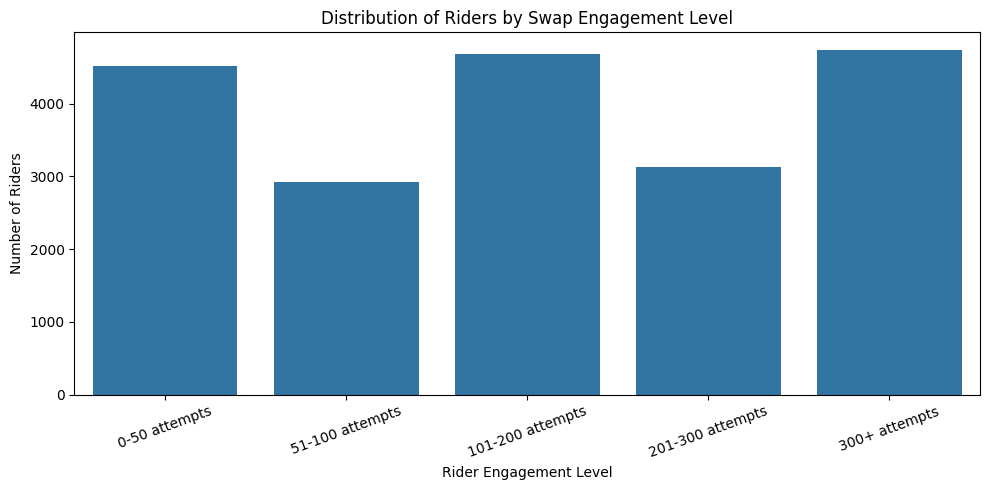

In [53]:
plt.figure(figsize=(10, 5))

sns.barplot(
    data=engagement_summary,
    x='engagement_band',
    y='riders'
)

plt.xlabel('Rider Engagement Level')
plt.ylabel('Number of Riders')
plt.title('Distribution of Riders by Swap Engagement Level')
plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

##6.2 Rider Characteristics and Engagement

To identify which rider segments are associated with stronger or weaker engagement, we compare average swap activity and completion performance across key rider characteristics.

The analysis focuses on plan type, vehicle class, declared shift, signup channel, age band, KYC verification status and home city. This helps identify whether engagement differences are concentrated in specific rider segments.

In [54]:
# Compare rider engagement across key rider characteristics

segment_columns = [
    'plan_type',
    'vehicle_class',
    'declared_shift',
    'signup_channel',
    'age_band',
    'kyc_verified',
    'home_city'
]

segment_analysis = []

for col in segment_columns:
    temp = (
        rider_engagement
        .groupby(col, dropna=False)
        .agg(
            riders=('rider_id', 'count'),
            avg_attempts=('total_attempts', 'mean'),
            avg_completed_swaps=('completed_swaps', 'mean'),
            avg_completion_rate=('completion_rate', 'mean')
        )
        .reset_index()
    )

    temp['segment'] = col
    temp = temp.rename(columns={col: 'category'})
    segment_analysis.append(temp)

segment_analysis = pd.concat(segment_analysis, ignore_index=True)

segment_analysis = segment_analysis[
    ['segment', 'category', 'riders',
     'avg_attempts', 'avg_completed_swaps',
     'avg_completion_rate']
]

segment_analysis

,segment,category,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
0,plan_type,partner_billed,12372,207.361623,194.781846,92.946080
1,plan_type,pay_as_you_go,5299,171.958294,161.993395,93.283757
2,plan_type,prepaid_pack,2329,171.888364,162.114641,93.119963
3,vehicle_class,2W,17107,201.846963,190.897001,93.828899
4,vehicle_class,3W,2893,146.566540,131.397857,88.484251
5,declared_shift,day,4366,190.963582,179.551306,93.042465
6,declared_shift,evening,5961,196.533300,184.774367,92.931621
7,declared_shift,mixed,3185,191.566719,180.148195,93.261168
8,declared_shift,night,2826,192.697098,181.166667,93.091496
9,declared_shift,NaN,3662,195.802567,184.243310,93.067651


In [55]:
# Show highest and lowest engagement segments for each characteristic

for segment in segment_analysis['segment'].unique():

    temp = segment_analysis[
        segment_analysis['segment'] == segment
    ].sort_values('avg_attempts', ascending=False)

    print(f"\n{segment.upper()}")
    display(temp)



PLAN_TYPE


,segment,category,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
0,plan_type,partner_billed,12372,207.361623,194.781846,92.946080
1,plan_type,pay_as_you_go,5299,171.958294,161.993395,93.283757
2,plan_type,prepaid_pack,2329,171.888364,162.114641,93.119963



VEHICLE_CLASS


,segment,category,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
3,vehicle_class,2W,17107,201.846963,190.897001,93.828899
4,vehicle_class,3W,2893,146.566540,131.397857,88.484251



DECLARED_SHIFT


...

,segment,category,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
15,age_band,25-34,6878,195.531695,183.858825,92.986804
16,age_band,35-44,4024,194.790258,183.259195,93.210875
17,age_band,45+,1943,193.012867,181.482244,93.245791
14,age_band,18-24,5608,192.282989,180.804565,92.996238
18,age_band,NaN,1547,190.667744,179.199095,92.936423



KYC_VERIFIED


,segment,category,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
19,kyc_verified,False,746,203.561662,189.910188,92.502162
20,kyc_verified,True,19254,193.474395,181.995222,93.077247



HOME_CITY


,segment,category,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
40,home_city,jaipur,29,244.172414,223.793103,90.320594
31,home_city,JAI,41,241.512195,223.317073,90.795084
33,home_city,MUM,49,229.428571,220.061224,95.974724
36,home_city,PUN,43,223.255814,211.186047,92.241689
22,home_city,Bangalore,32,222.000000,213.468750,93.361463
38,home_city,bengaluru,50,215.240000,205.720000,95.231290
25,home_city,Delhi,25,215.240000,196.720000,89.115123
30,home_city,Hyderabad,3396,205.220554,191.523557,92.001212
26,home_city,Delhi NCR,3783,198.063177,183.507534,91.337634
35,home_city,New Delhi,42,196.023810,183.404762,92.728019


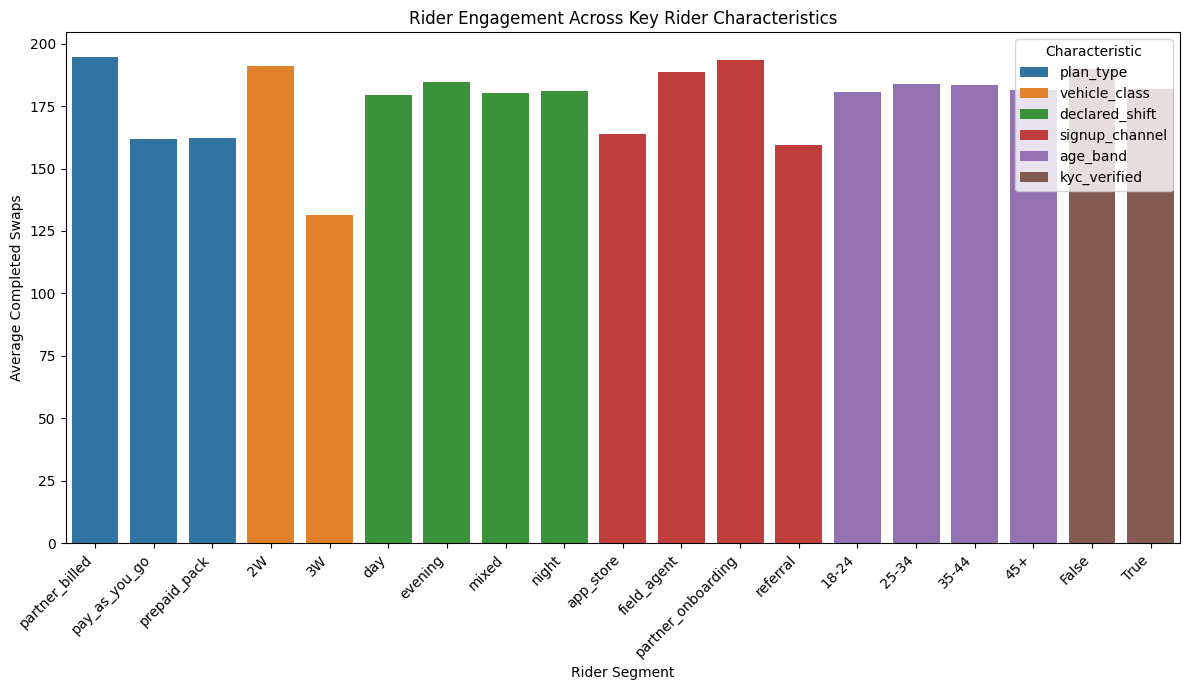

In [56]:
import seaborn as sns
import matplotlib.pyplot as plt

# Exclude very high-cardinality city categories for the first comparison
plot_segments = ['plan_type', 'vehicle_class', 'declared_shift',
                 'signup_channel', 'age_band', 'kyc_verified']

plot_data = segment_analysis[
    segment_analysis['segment'].isin(plot_segments)
].copy()

plt.figure(figsize=(12, 7))

sns.barplot(
    data=plot_data,
    x='category',
    y='avg_completed_swaps',
    hue='segment',
    errorbar=None
)

plt.xlabel('Rider Segment')
plt.ylabel('Average Completed Swaps')
plt.title('Rider Engagement Across Key Rider Characteristics')
plt.xticks(rotation=45, ha='right')
plt.legend(title='Characteristic')
plt.tight_layout()
plt.show()

### Vehicle Class and Rider Engagement

Vehicle type may influence rider engagement because different vehicle classes can have different operating patterns and swap requirements.

We compare average completed swaps and completion rates across vehicle classes to determine whether rider engagement differs materially between 2W and 3W riders.


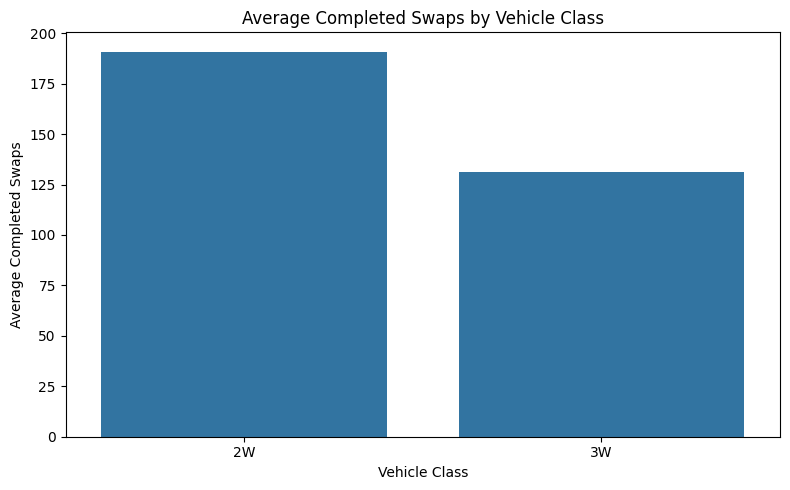

In [57]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_analysis[
        segment_analysis['segment'] == 'vehicle_class'
    ],
    x='category',
    y='avg_completed_swaps',
    errorbar=None
)

plt.xlabel('Vehicle Class')
plt.ylabel('Average Completed Swaps')
plt.title('Average Completed Swaps by Vehicle Class')
plt.tight_layout()
plt.show()

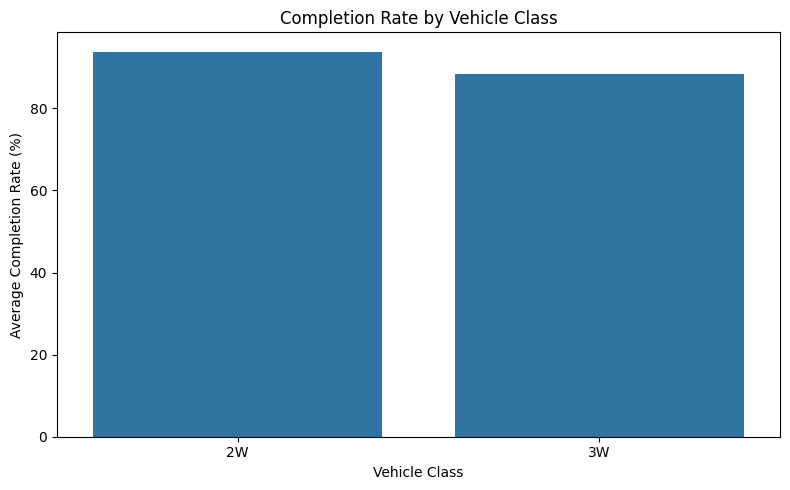

In [58]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=segment_analysis[
        segment_analysis['segment'] == 'vehicle_class'
    ],
    x='category',
    y='avg_completion_rate',
    errorbar=None
)

plt.xlabel('Vehicle Class')
plt.ylabel('Average Completion Rate (%)')
plt.title('Completion Rate by Vehicle Class')
plt.tight_layout()
plt.show()

### Key Finding

Vehicle class shows a clear difference in rider engagement.

2W riders average approximately 191 completed swaps, compared with approximately 131 completed swaps for 3W riders. Completion performance also differs, with 2W riders achieving approximately 93.8% completion compared with 88.5% for 3W riders.

This indicates that 3W riders represent a relatively lower-engagement segment and also experience weaker swap completion performance. The difference is therefore relevant to both rider activity and service reliability.

## 6.2 Engagement by Plan Type

Plan type may influence rider engagement because different plans can reflect different usage patterns and levels of dependence on the swapping network.

We compare average completed swaps and completion rates across plan types to identify whether engagement differs meaningfully between rider groups.

In [59]:
plan_engagement = (
    rider_engagement
    .groupby('plan_type')
    .agg(
        riders=('rider_id', 'count'),
        avg_attempts=('total_attempts', 'mean'),
        avg_completed_swaps=('completed_swaps', 'mean'),
        avg_completion_rate=('completion_rate', 'mean')
    )
    .reset_index()
)

display(plan_engagement)

,plan_type,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
0,partner_billed,12372,207.361623,194.781846,92.946080
1,pay_as_you_go,5299,171.958294,161.993395,93.283757
2,prepaid_pack,2329,171.888364,162.114641,93.119963


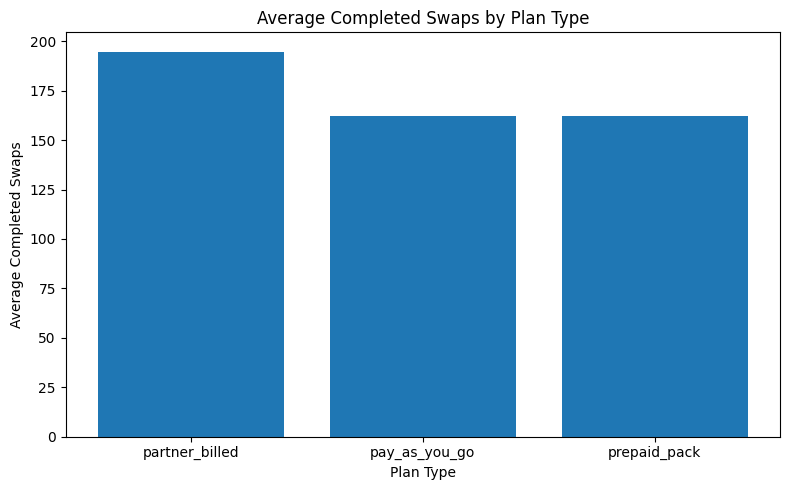

In [60]:
plt.figure(figsize=(8, 5))

plt.bar(
    plan_engagement['plan_type'],
    plan_engagement['avg_completed_swaps']
)

plt.title('Average Completed Swaps by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Average Completed Swaps')

plt.tight_layout()
plt.show()

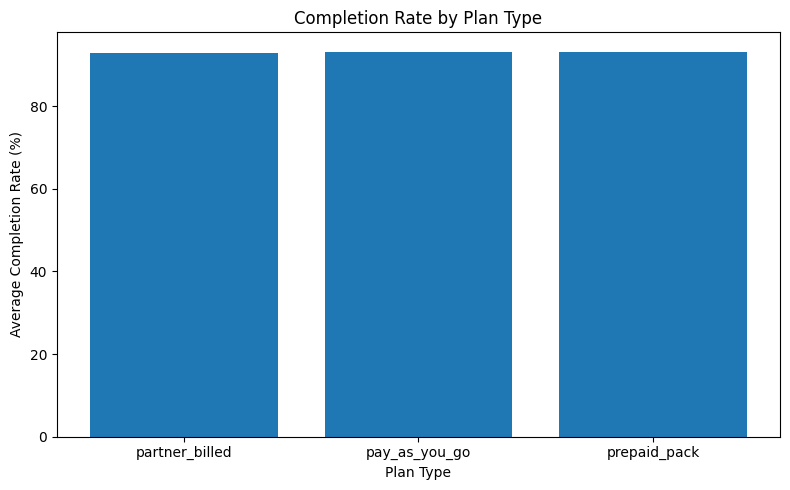

In [61]:
plt.figure(figsize=(8, 5))

plt.bar(
    plan_engagement['plan_type'],
    plan_engagement['avg_completion_rate']
)

plt.title('Completion Rate by Plan Type')
plt.xlabel('Plan Type')
plt.ylabel('Average Completion Rate (%)')

plt.tight_layout()
plt.show()

### Key Finding

Plan type shows a clear difference in rider engagement, but only a very small difference in completion performance.

- **Partner-billed riders** show the highest engagement, averaging approximately **194.8 completed swaps**, compared with **162.0** for pay-as-you-go and **162.1** for prepaid-pack riders.
- Despite the higher activity level, completion rates are very similar across plans, ranging from approximately **92.9% to 93.3%**.
- This indicates that the main difference across plan types is **usage intensity rather than swap reliability**.
- The higher activity among partner-billed riders therefore appears to be associated with greater network usage rather than a materially different ability to complete swaps.

### Analysis

The results suggest that plan type is primarily associated with the **volume of rider engagement** rather than the quality of service experienced during swaps. Partner-billed riders complete substantially more swaps on average, while their completion rate remains broadly comparable with other plan types. Therefore, plan type should be considered an important segmentation variable for understanding demand intensity, but it does not by itself indicate a major rider-retention risk based on completion performance.

## 6.3 Engagement by Declared Shift

Rider usage patterns may vary by the time of day in which riders typically operate. We therefore compare engagement and completion performance across declared operating shifts to determine whether particular shift groups exhibit materially different usage or service outcomes.

In [62]:
shift_engagement = (
    rider_engagement
    .groupby('declared_shift', dropna=False)
    .agg(
        riders=('rider_id', 'count'),
        avg_attempts=('total_attempts', 'mean'),
        avg_completed_swaps=('completed_swaps', 'mean'),
        avg_completion_rate=('completion_rate', 'mean')
    )
    .reset_index()
)

display(shift_engagement)

,declared_shift,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
0,day,4366,190.963582,179.551306,93.042465
1,evening,5961,196.533300,184.774367,92.931621
2,mixed,3185,191.566719,180.148195,93.261168
3,night,2826,192.697098,181.166667,93.091496
4,NaN,3662,195.802567,184.243310,93.067651


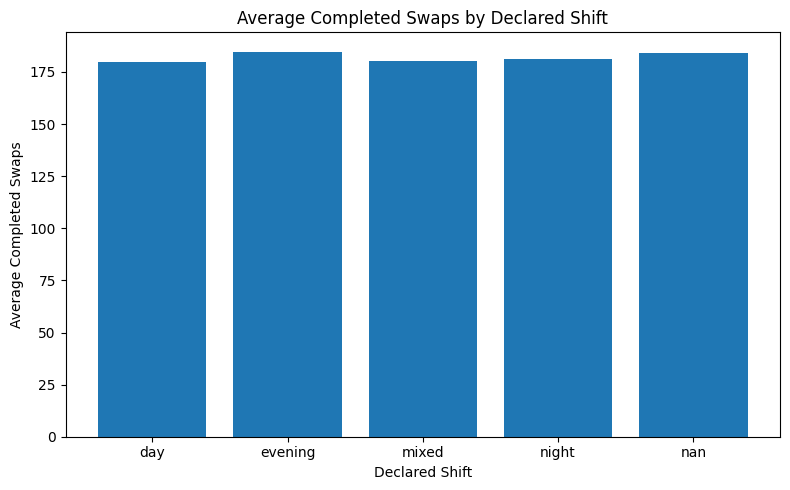

In [63]:
plt.figure(figsize=(8, 5))

plt.bar(
    shift_engagement['declared_shift'].astype(str),
    shift_engagement['avg_completed_swaps']
)

plt.title('Average Completed Swaps by Declared Shift')
plt.xlabel('Declared Shift')
plt.ylabel('Average Completed Swaps')

plt.tight_layout()
plt.show()

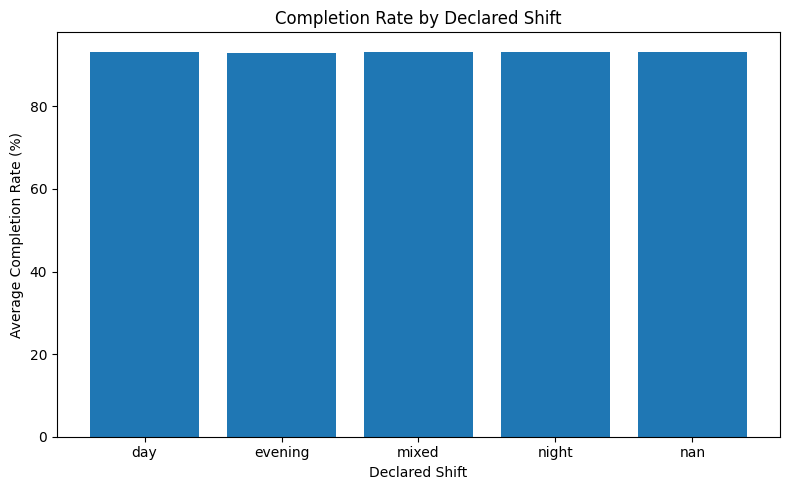

In [64]:
plt.figure(figsize=(8, 5))

plt.bar(
    shift_engagement['declared_shift'].astype(str),
    shift_engagement['avg_completion_rate']
)

plt.title('Completion Rate by Declared Shift')
plt.xlabel('Declared Shift')
plt.ylabel('Average Completion Rate (%)')

plt.tight_layout()
plt.show()

### Key Finding

Declared shift does not appear to be a major differentiator of rider engagement or swap reliability.

- Average completed swaps are relatively close across all shift groups, ranging from approximately **179.6** for day-shift riders to **184.8** for evening riders.
- Completion rates are also highly consistent, ranging from approximately **92.9% to 93.3%**.
- The **evening** group records the highest average completed swaps, while the **mixed** group has the highest completion rate, but the differences are small.
- Riders with missing shift information show broadly similar performance, suggesting that the missing values do not materially distort the overall pattern.

### Analysis

The results indicate that declared operating shift has limited explanatory power for rider engagement. Although evening riders record slightly higher average completed swaps, the difference is relatively small and completion rates remain almost identical across groups. Therefore, shift timing does not emerge as a major rider-retention or engagement risk factor in the observed data. Other rider characteristics are likely to provide stronger segmentation signals.

## 6.4 Engagement by Signup Channel

The channel through which riders join the platform may be associated with differences in rider engagement. We compare average completed swaps and completion rates across signup channels to identify whether acquisition channels are associated with different levels of subsequent activity.

In [65]:
signup_engagement = (
    rider_engagement
    .groupby('signup_channel', dropna=False)
    .agg(
        riders=('rider_id', 'count'),
        avg_attempts=('total_attempts', 'mean'),
        avg_completed_swaps=('completed_swaps', 'mean'),
        avg_completion_rate=('completion_rate', 'mean')
    )
    .reset_index()
)

display(signup_engagement)

,signup_channel,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
0,app_store,4215,173.887070,163.873310,93.219920
1,field_agent,4144,200.326014,188.495898,93.154032
2,partner_onboarding,9376,205.865188,193.304181,92.884776
3,referral,2265,169.419868,159.618543,93.278580


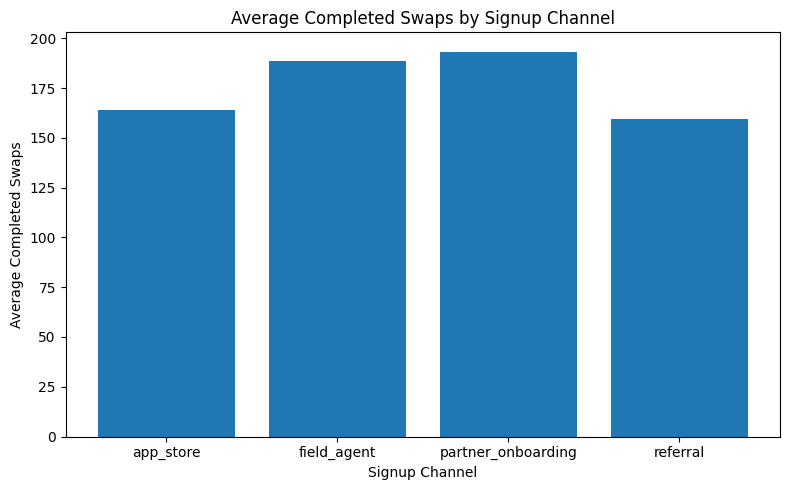

In [66]:
plt.figure(figsize=(8, 5))

plt.bar(
    signup_engagement['signup_channel'].astype(str),
    signup_engagement['avg_completed_swaps']
)

plt.title('Average Completed Swaps by Signup Channel')
plt.xlabel('Signup Channel')
plt.ylabel('Average Completed Swaps')

plt.tight_layout()
plt.show()

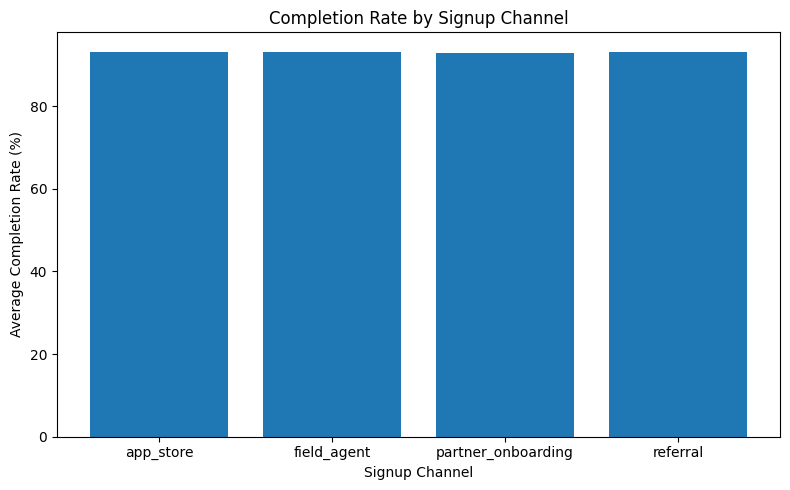

In [67]:
plt.figure(figsize=(8, 5))

plt.bar(
    signup_engagement['signup_channel'].astype(str),
    signup_engagement['avg_completion_rate']
)

plt.title('Completion Rate by Signup Channel')
plt.xlabel('Signup Channel')
plt.ylabel('Average Completion Rate (%)')

plt.tight_layout()
plt.show()

### Key Finding

Signup channel is associated with meaningful differences in rider engagement, but not with materially different completion performance.

- **Partner-onboarding riders** have the highest average engagement, with approximately **193.3 completed swaps**, followed by **field-agent riders** at **188.5**.
- **App-store** and **referral** riders show lower average completed swaps, at approximately **163.9** and **159.6**, respectively.
- Despite these differences in activity, completion rates remain tightly clustered between approximately **92.9% and 93.3%** across all channels.
- Therefore, signup channel appears to be more relevant for understanding **rider usage intensity** than swap reliability.

### Analysis

The results indicate that acquisition channel is associated with different levels of subsequent rider engagement. Riders entering through partner onboarding and field agents exhibit substantially higher swap activity than those acquired through the app store or referrals. However, the nearly identical completion rates across channels suggest that these differences are primarily related to **usage intensity rather than service reliability**. This makes signup channel useful for rider segmentation and engagement analysis, but it does not by itself identify a major retention risk through failed swaps.

## 6.5 Engagement by Age Band

Rider demographics may also be associated with differences in platform engagement. We compare swap activity and completion performance across age bands to determine whether engagement or service outcomes vary systematically with rider age.

In [68]:
age_engagement = (
    rider_engagement
    .groupby('age_band', dropna=False)
    .agg(
        riders=('rider_id', 'count'),
        avg_attempts=('total_attempts', 'mean'),
        avg_completed_swaps=('completed_swaps', 'mean'),
        avg_completion_rate=('completion_rate', 'mean')
    )
    .reset_index()
)

display(age_engagement)

,age_band,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
0,18-24,5608,192.282989,180.804565,92.996238
1,25-34,6878,195.531695,183.858825,92.986804
2,35-44,4024,194.790258,183.259195,93.210875
3,45+,1943,193.012867,181.482244,93.245791
4,NaN,1547,190.667744,179.199095,92.936423


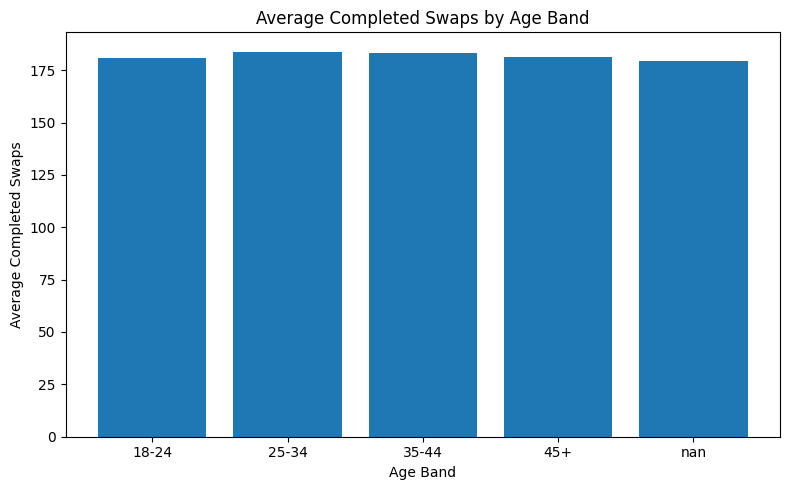

In [69]:
plt.figure(figsize=(8, 5))

plt.bar(
    age_engagement['age_band'].astype(str),
    age_engagement['avg_completed_swaps']
)

plt.title('Average Completed Swaps by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Average Completed Swaps')

plt.tight_layout()
plt.show()

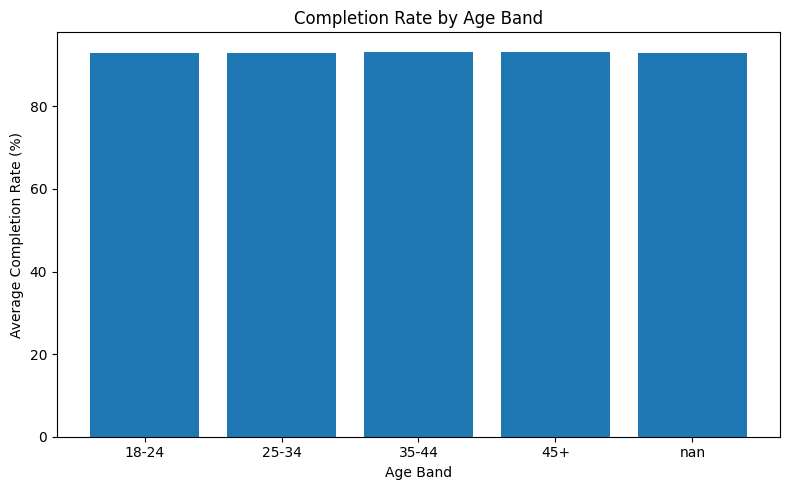

In [70]:
plt.figure(figsize=(8, 5))

plt.bar(
    age_engagement['age_band'].astype(str),
    age_engagement['avg_completion_rate']
)

plt.title('Completion Rate by Age Band')
plt.xlabel('Age Band')
plt.ylabel('Average Completion Rate (%)')

plt.tight_layout()
plt.show()

### Key Finding

Age band shows very limited variation in both rider engagement and swap completion performance.

- Average completed swaps remain tightly clustered, ranging from approximately **179.2** among riders with missing age information to **183.9** among riders aged **25–34**.
- Completion rates are similarly stable, ranging from approximately **93.0% to 93.2%** across the observed age groups.
- The **25–34** group records the highest average completed swaps, while the **35–44** group has the highest completion rate, but the differences are marginal.
- Overall, age does not appear to be a strong differentiator of rider engagement or swap reliability in the observed data.

### Analysis

The results suggest that rider age has limited explanatory power for engagement or retention-related service performance. Although the 25–34 group shows slightly higher activity, the differences in both completed swaps and completion rates are small across age groups. Therefore, age should be treated primarily as a segmentation variable rather than a major driver of rider engagement or churn risk in this analysis.

## 6.6 Engagement by KYC Verification Status

KYC verification may influence rider engagement by distinguishing verified riders from those who have not completed verification. We compare swap activity and completion performance across KYC status to determine whether verification is associated with different rider behaviour.

In [71]:
kyc_engagement = (
    rider_engagement
    .groupby('kyc_verified', dropna=False)
    .agg(
        riders=('rider_id', 'count'),
        avg_attempts=('total_attempts', 'mean'),
        avg_completed_swaps=('completed_swaps', 'mean'),
        avg_completion_rate=('completion_rate', 'mean')
    )
    .reset_index()
)

display(kyc_engagement)

,kyc_verified,riders,avg_attempts,avg_completed_swaps,avg_completion_rate
0,False,746,203.561662,189.910188,92.502162
1,True,19254,193.474395,181.995222,93.077247


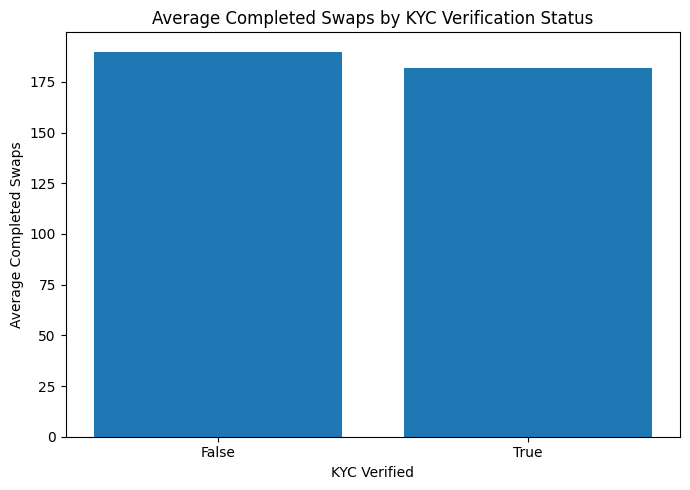

In [72]:
plt.figure(figsize=(7, 5))

plt.bar(
    kyc_engagement['kyc_verified'].astype(str),
    kyc_engagement['avg_completed_swaps']
)

plt.title('Average Completed Swaps by KYC Verification Status')
plt.xlabel('KYC Verified')
plt.ylabel('Average Completed Swaps')

plt.tight_layout()
plt.show()

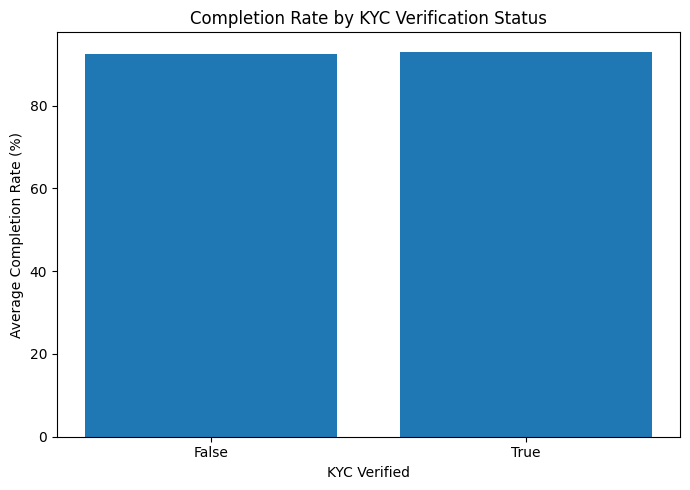

In [73]:
plt.figure(figsize=(7, 5))

plt.bar(
    kyc_engagement['kyc_verified'].astype(str),
    kyc_engagement['avg_completion_rate']
)

plt.title('Completion Rate by KYC Verification Status')
plt.xlabel('KYC Verified')
plt.ylabel('Average Completion Rate (%)')

plt.tight_layout()
plt.show()

### Key Finding — KYC Verification

KYC status shows only a modest difference in rider engagement. Non-KYC-verified riders record higher average attempts (203.6) and completed swaps (189.9) than KYC-verified riders (193.5 attempts and 182.0 completed swaps).

However, the completion rates are broadly similar at 92.5% for non-verified riders versus 93.1% for verified riders. This suggests that KYC verification is not a major differentiator of swap completion performance in the observed data.

The difference in engagement should therefore be interpreted as an association rather than evidence that KYC status directly drives rider activity.

## Q6 — Final Answer

**Answer:** Rider engagement varies more strongly by operational and commercial characteristics than by demographic attributes. Vehicle class is the clearest differentiator: 2W riders average approximately 190 completed swaps compared with approximately 131 for 3W riders, with completion rates of 93.8% and 88.5% respectively.

Plan type and signup channel also show meaningful differences in engagement volume. Partner-billed riders average approximately 195 completed swaps, compared with approximately 162 for pay-as-you-go and prepaid-pack riders. Similarly, riders acquired through partner onboarding and field agents show higher activity than app-store and referral cohorts.

In contrast, declared shift and age band show relatively limited variation in completion performance, with completion rates remaining close to 93% across most groups. KYC status also shows only a modest difference, with similar completion rates for verified and non-verified riders.

Overall, the analysis indicates that rider retention and engagement risk is concentrated more around **vehicle type and commercial/onboarding structure** than around demographic characteristics. The results identify associations in observed rider activity rather than causal effects.

# Final Executive Summary

## Six-Question Answer Sheet

| Question | Status | Final evidence required |
|---|---|---|
| Q1 Network Performance | Existing analysis | Monthly demand + completion trend |
| Q2 Service Failures & CX | Existing + queue analysis | Failure mix + wait-time association |
| Q3 Station & Geographic Patterns | Existing station analysis | Volume + completion + battery-failure hotspots |
| Q4 Battery & Equipment | Existing analysis | SOC/SOH + energy requirement relationships |
| Q5 Pricing & Economics | Existing analysis | Revenue + energy cost + tariff drivers |
| Q6 Retention | **Needs analysis** | Rider churn/retention root causes |

## Presentation rule
Every Q should end with a short, decision-oriented **Key Finding**. Do not repeat the same chart in multiple questions; reference the earlier result when it is already sufficient.
